In [1]:
# import os
# import cmdstanpy

# cmdstan_base_dir = "/home/onyxia/work/cmdstan"

# # 1. Détection et compilation conditionnelle du backend C++
# if not os.path.exists(cmdstan_base_dir) or not any(d.startswith("cmdstan-") for d in os.listdir(cmdstan_base_dir)):
#     print(f"Absence du backend C++. Téléchargement et compilation initiés dans {cmdstan_base_dir}...")
#     # La compilation nécessite g++ et make (déjà présents sur l'image VSCode Python d'Onyxia)
#     cmdstanpy.install_cmdstan(dir=cmdstan_base_dir)

# # 2. Assignation stricte du chemin 
# try:
#     installed_versions = [d for d in os.listdir(cmdstan_base_dir) if d.startswith("cmdstan-")]
#     # Trie pour garantir la sélection de la version la plus récente si plusieurs existent
#     installed_versions.sort(reverse=True) 
    
#     cmdstan_path = os.path.join(cmdstan_base_dir, installed_versions[0])
#     cmdstanpy.set_cmdstan_path(cmdstan_path)
#     print(f"Liaison matérielle CmdStan établie sur : {cmdstanpy.cmdstan_path()}")
# except Exception as e:
#     raise RuntimeError(f"Échec critique lors de la résolution des binaires CmdStan : {e}")



import psutil
import threading
import time
import numpy as np

class ClusterMonitor:
    def __init__(self, interval=2.0):
        """
        interval : fréquence d'échantillonnage en secondes.
        2.0s est optimal pour garantir un surcoût computationnel strictement nul.
        """
        self.interval = interval
        self.active = False
        self.ram_gi = []
        self.cpu_cores = []
        
    def _poll(self):
        main_proc = psutil.Process()
        main_proc.cpu_percent() # Initialisation des registres internes psutil
        
        while self.active:
            mem_bytes = 0
            cpu_pct = 0.0
            
            try:
                # Capture atomique de l'arbre des processus (Python + C++ CmdStan)
                procs = [main_proc] + main_proc.children(recursive=True)
                for p in procs:
                    try:
                        mem_bytes += p.memory_info().rss
                        # 100% CPU = 1 Coeur (Ci). interval=None pour calcul asynchrone.
                        cpu_pct += p.cpu_percent(interval=None)
                    except psutil.NoSuchProcess:
                        pass # Le processus C++ s'est terminé entre deux itérations
                        
                self.ram_gi.append(mem_bytes / (1024**3))
                self.cpu_cores.append(cpu_pct / 100.0)
            except Exception:
                pass
                
            time.sleep(self.interval)

    def start(self):
        self.active = True
        self.t = threading.Thread(target=self._poll, daemon=True)
        self.t.start()

    def stop(self):
        self.active = False
        self.t.join()
        
        if not self.ram_gi:
            return
            
        ram_mean, ram_peak = np.mean(self.ram_gi), np.max(self.ram_gi)
        cpu_mean, cpu_peak = np.mean(self.cpu_cores), np.max(self.cpu_cores)
        
        print("\n" + "="*45)
        print(" DIAGNOSTIC MATÉRIEL (Onyxia) ".center(45))
        print("="*45)
        print(f" RAM (Gi)    | Moyenne : {ram_mean:>6.2f} | Pic : {ram_peak:>6.2f}")
        print(f" CPU (Cores) | Moyenne : {cpu_mean:>6.2f} | Pic : {cpu_peak:>6.2f}")
        print("="*45 + "\n")

## RHO PAR DYADE, MULTITHREADING, hurdle logit ~alpha + gamma + X_h*beta_h + beta_lag_m49[cluster_h]*is_mig_lag

In [2]:
import warnings

import os
import cmdstanpy
from cmdstanpy import CmdStanModel

import pandas as pd
import numpy as np

import xgboost as xgb
import re
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve , roc_auc_score, accuracy_score
from itertools import product

#from sklearn.ensemble import RandomForestClassifier
from scipy.special import logit as scipy_logit

warnings.filterwarnings('ignore')
np.random.seed(42)

DATA_PATH  = "../data/panel_june_filled.csv"
#STAN_FILE  = "../STAN/HMC_hurdle_regression_vectorized.stan"
OUTPUT_DIR = "./stan_outputs_tmux"
os.makedirs(OUTPUT_DIR, exist_ok=True)


/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## D'ici la réunion 8 Juillet 
* réfléchir à un plan/draft; lire du JRSS A 
* dataset: compléter ou réfléchir à exclure proprement les états problématiques. covariables concernées: LA LL urban ; PSE DROM-TOM etc.
* relancer simulation avec Hurdle logit et rf / xgb, et quantifier rho dyadique/cluster 
* résoudre faiblesse hyper-régression
* trancher méthode W_FP
* tester BART sur subsamples et trancher ; on peut le mentionner en Discussion. 


### tester gdpcap_lag1 pour l'horizon 1; réfléchir à la dimension temporelle (prédiction 2011-2014? =/= 2015?)



Var(flow_ij) = E[Var(flow | p_ij)] + Var(E[flow | p_ij])
                    ^ variance volume          ^ variance hurdle
ce deuxième terme est nul quand p_ij est donnée exogène du XGBoost

In [3]:
# Sampling parameters
N_CHAINS        = 4
PARALLEL_CHAINS = 4
ITER_WARMUP     = 500
ITER_SAMPLING   = 501
THIN            = 1
MAX_TREEDEPTH   = 12
ADAPT_DELTA     = 0.95
N_DRAWS         = ITER_SAMPLING // THIN

# Contrôle matériel : vectorized ou multithreading
USE_MULTITHREADING = False  # True (reduce_sum) / False (Vectorisation standard)


# SUBSET DE PAYS (modifier RUN_SIZE uniquement)

RUN_SIZE = 5
# _LABELS  = {1: '50 pays', 2: '80 pays', 3: '110 pays', 4: '140 pays', 5: '190 pays (complet)'}


In [4]:
df_main = pd.read_csv(DATA_PATH)
df = df_main[df_main['orig'] != df_main['dest']].copy()

PAYS_EXCLURE = {
    'SSD', 'CUW', #'MNE', 'TLS', 
    'GUM', 'MYT', 'VIR', 'CLI', # on va essayer d'intégrer ceux-là manuellement (manque le PIB)
}
df = df[
    ~df['orig'].isin(PAYS_EXCLURE) &
    ~df['dest'].isin(PAYS_EXCLURE)
].copy()

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
print(f"{df['orig'].nunique()} pays après exclusions")

190 pays après exclusions


In [5]:
# 1. Base 50 : Échantillon fondamental. Diversité géographique maximale et intégration des plus grands pôles.
PAYS_SUBSET_50 = {
    # Amérique du Nord & Sud
    'USA', 'CAN', 'MEX', 'BRA', 'ARG', 'COL', 'CHL', 'PER', 'VEN',
    # Europe
    'FRA', 'DEU', 'GBR', 'ITA', 'ESP', 'POL', 'RUS', 'UKR', 'SWE', 'NLD', 'ROU',
    # Asie & Moyen-Orient
    'CHN', 'IND', 'JPN', 'KOR', 'IDN', 'PAK', 'BGD', 'PHL', 'VNM', 'TUR', 'IRN', 'SAU', 'THA', 'MYS', 'KAZ',
    # Afrique
    'NGA', 'ETH', 'EGY', 'COD', 'ZAF', 'TZA', 'KEN', 'DZA', 'MAR', 'GHA', 'CIV', 'AGO', 'SEN',
    # Océanie
    'AUS', 'NZL'
}

# 2. Base 80 : +30 pays. Densification des régions d'Europe continentale, Asie centrale/sud, et Afrique subsaharienne.
PAYS_SUBSET_80 = PAYS_SUBSET_50 | {
    'NOR', 'FIN', 'DNK', 'CHE', 'AUT', 'BEL', 'GRC', 'CZE',
    'BOL', 'ECU', 'URY', 'GTM', 'CUB', 'DOM',
    'IRQ', 'ISR', 'ARE', 'UZB', 'MMR', 'LKA', 'NPL', 'AFG',
    'CMR', 'MLI', 'BFA', 'MOZ', 'ZMB', 'RWA', 'TUN', 'SDN'
}

# 3. Base 110 : +30 pays. Ajout de l'Europe de l'Est, Amérique centrale, péninsule arabique et Afrique francophone/australe.
PAYS_SUBSET_110 = PAYS_SUBSET_80 | {
    'HUN', 'PRT', 'IRL', 'BGR', 'SRB', 'HRV', 'BLR', 'SVK',
    'HND', 'SLV', 'NIC', 'CRI', 'PAN', 'PRY',
    'JOR', 'LBN', 'KWT', 'OMN', 'YEM', 'KHM', 'SGP',
    'TCD', 'NER', 'GIN', 'BDI', 'SOM', 'MWI', 'COG', 'GAB', 'NAM'
}

# 4. Base 140 : +30 pays. Ajout des pays baltes, Balkans, Caraïbes, Asie mineure et Océanie isolée.
PAYS_SUBSET_140 = PAYS_SUBSET_110 | {
    'LTU', 'LVA', 'EST', 'SVN', 'MKD', 'BIH', 'ALB', 'MDA',
    'HTI', 'JAM', 'TTO', 'BHS', 'GUY', 'SUR',
    'QAT', 'BHR', 'SYR', 'TJK', 'KGZ', 'LAO', 'MNG',
    'LBY', 'MRT', 'TGO', 'BEN', 'LBR', 'SLE', 'CAF',
    'PNG', 'FJI'
}


_SUBSETS = {1: PAYS_SUBSET_50, 2: PAYS_SUBSET_80, 3: PAYS_SUBSET_110, 4: PAYS_SUBSET_140, 5: None}
_LABELS  = {1: '50 pays', 2: '80 pays', 3: '110 pays', 4: '140 pays', 5: '190 pays (complet)'}


if RUN_SIZE < 5:
    pays_subset = _SUBSETS[RUN_SIZE]
    # Application des masques stricts sur orig et dest
    df = df[df['orig'].isin(pays_subset) & df['dest'].isin(pays_subset)].copy()
N_pays = df['orig'].nunique()
print(f"Run : {df['orig'].nunique()} pays dans le panel")

Run : 190 pays dans le panel


In [6]:
# clustering M49

ISO3_TO_M49_SUBREGION = {
    'DNK': 11, 'EST': 11, 'FIN': 11, 'ISL': 11, 'IRL': 11, 'LVA': 11, 'LTU': 11, 'NOR': 11, 'SWE': 11, 'GBR': 11,
    'ALB': 12, 'AND': 12, 'BIH': 12, 'HRV': 12, 'GRC': 12, 'ITA': 12, 'MLT': 12, 'MNE': 12, 'MKD': 12, 'PRT': 12, 'SRB': 12, 'SVN': 12, 'ESP': 12,
    'AUT': 13, 'BEL': 13, 'FRA': 13, 'DEU': 13, 'LIE': 13, 'LUX': 13, 'MCO': 13, 'NLD': 13, 'CHE': 13,
    'BLR': 14, 'BGR': 14, 'CZE': 14, 'HUN': 14, 'POL': 14, 'MDA': 14, 'ROU': 14, 'RUS': 14, 'SVK': 14, 'UKR': 14,
    'DZA': 15, 'EGY': 15, 'LBY': 15, 'MAR': 15, 'SDN': 15, 'TUN': 15, 'ESH': 15,
    'BEN': 16, 'BFA': 16, 'CPV': 16, 'CIV': 16, 'GMB': 16, 'GHA': 16, 'GIN': 16, 'GNB': 16, 'LBR': 16, 'MLI': 16, 'MRT': 16, 'NER': 16, 'NGA': 16, 'SEN': 16, 'SLE': 16, 'TGO': 16,
    'BDI': 17, 'COM': 17, 'DJI': 17, 'ERI': 17, 'ETH': 17, 'KEN': 17, 'MDG': 17, 'MWI': 17, 'MUS': 17, 'MOZ': 17, 'REU': 17, 'RWA': 17, 'SYC': 17, 'SOM': 17, 'SSD': 17, 'TZA': 17, 'UGA': 17, 'ZMB': 17, 'ZWE': 17,
    'AGO': 18, 'CMR': 18, 'CAF': 18, 'TCD': 18, 'COD': 18, 'COG': 18, 'GNQ': 18, 'GAB': 18, 'STP': 18,
    'BWA': 19, 'LSO': 19, 'NAM': 19, 'ZAF': 19, 'SWZ': 19,
    'CAN': 21, 'MEX': 21, 'USA': 21,
    'BLZ': 22, 'CRI': 22, 'SLV': 22, 'GTM': 22, 'HND': 22, 'NIC': 22, 'PAN': 22,
    'ATG': 23, 'BHS': 23, 'BRB': 23, 'CUB': 23, 'DMA': 23, 'DOM': 23, 'GLP': 23, 'GRD': 23, 'HTI': 23, 'JAM': 23, 'KNA': 23, 'LCA': 23, 'MTQ': 23, 'VCT': 23, 'TTO': 23, 'ABW': 23, 'PRI': 23,
    'ARG': 24, 'BOL': 24, 'BRA': 24, 'CHL': 24, 'COL': 24, 'ECU': 24, 'GUF': 24, 'GUY': 24, 'PRY': 24, 'PER': 24, 'SUR': 24, 'URY': 24, 'VEN': 24,
    'CHN': 30, 'HKG': 30, 'JPN': 30, 'KOR': 30, 'MAC': 30, 'MNG': 30, 'PRK': 30,
    'AFG': 34, 'BGD': 34, 'BTN': 34, 'IND': 34, 'IRN': 34, 'MDV': 34, 'NPL': 34, 'PAK': 34, 'LKA': 34,
    'BRN': 35, 'KHM': 35, 'IDN': 35, 'LAO': 35, 'MYS': 35, 'MMR': 35, 'PHL': 35, 'SGP': 35, 'THA': 35, 'TLS': 35, 'VNM': 35,
    'ARM': 145, 'AZE': 145, 'BHR': 145, 'CYP': 145, 'GEO': 145, 'IRQ': 145, 'ISR': 145, 'JOR': 145, 'KWT': 145, 'LBN': 145, 'OMN': 145, 'QAT': 145, 'SAU': 145, 'PSE': 145, 'SYR': 145, 'TUR': 145, 'ARE': 145, 'YEM': 145,
    'KAZ': 143, 'KGZ': 143, 'TJK': 143, 'TKM': 143, 'UZB': 143,
    'AUS': 53, 'FJI': 53, 'NZL': 53, 'PNG': 53, 'SLB': 53, 'VUT': 53, 'WSM': 53, 'TON': 53, 'KIR': 53, 'FSM': 53, 'GUM': 53, 'NCL': 53, 'PYF': 53,
}

SUBREGION_LABELS = {
    11: 'Europe du Nord', 12: 'Europe du Sud', 13: "Europe de l'Ouest", 14: "Europe de l'Est",
    15: 'Afrique du Nord', 16: "Afrique de l'Ouest", 17: "Afrique de l'Est", 18: 'Afrique Centrale', 19: 'Afrique Australe',
    21: 'Amerique du Nord', 22: 'Amerique Centrale', 23: 'Caraibes', 24: 'Amerique du Sud',
    30: "Asie de l'Est", 34: 'Asie du Sud', 35: 'Asie du Sud-Est',
    143: 'Asie Centrale', 145: "Asie de l'Ouest", 53: 'Oceanie', 99: 'Non classifie'
}

df['m49_brut'] = df['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
_UNIQUE_M49_PRESENT = sorted(df['m49_brut'].unique())
_M49_TO_STAN = {m49: i + 1 for i, m49 in enumerate(_UNIQUE_M49_PRESENT)}
stan_to_m49 = {v: k for k, v in _M49_TO_STAN.items()}
df['continent_orig'] = df['m49_brut'].map(_M49_TO_STAN)
K_clusters = len(_M49_TO_STAN)
print(f"{K_clusters} clusters M49")

19 clusters M49


In [7]:
# df['is_migration'] = (df['flow'] > 0).astype(int)
# df['log_flow']     = np.where(df['flow'] > 0, np.log(df['flow']), np.nan)
# df['log_flow_lag'] = df.groupby(['orig', 'dest'])['log_flow'].shift(1)
# df['is_mig_lag']   = df.groupby(['orig', 'dest'])['is_migration'].shift(1)
# df['log_D_ij']     = np.log(df['D_ij'].replace(0, np.nan))
# df['log_D_ij_sq']  = df['log_D_ij'] ** 2
# df['logD_times_LB'] = df['log_D_ij'] * df['LB_ij']


df['dyad'] = df['orig'] + "_" + df['dest']

# df['instability_o'] = df['v2x_clphy_o_lag1'] - df['v2x_polyarchy_o_lag1']
# df['instability_d'] = df['v2x_clphy_d_lag1'] - df['v2x_polyarchy_d_lag1']

df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)

# inutile déjà calculé par build_dataset, à supprimer: 
# for col_base, group_key in [
#     ('intensity_level_o_lag1', 'orig'),
#     ('type_of_conflict_o_lag1', 'orig'),
#     ('intensity_level_d_lag1', 'dest'),
#     ('type_of_conflict_d_lag1', 'dest'),
# ]:
#     new_col = f'{col_base}_persist'
#     df[new_col] = df.groupby([group_key, 'dest' if group_key == 'orig' else 'orig'])[col_base] \
#         .transform(lambda x: x.shift(1).rolling(2, min_periods=1).mean())

df = df.dropna(subset=['is_mig_lag']).reset_index(drop=True)

GRAVITY_VARS_RAW = ['P_it', 'P_jt', 'PSR_i', 'PSR_j', 'IMR_it', 'IMR_jt', 'urban_it', 'urban_jt', 'LA_i', 'LA_j']
for raw in GRAVITY_VARS_RAW:
    df[f'log_{raw}'] = np.log(df[raw].replace(0, np.nan)) # créer les variables log

In [8]:
# === Momentum du flux : Δ = log Y_{t-1} − log Y_{t-2} (pente, absente de l'ARX(1)) ===
df = df.sort_values(['dyad', 'year'])
lag1_raw = df.groupby('dyad')['log_flow'].shift(1)         # brut (NaN si fermé), PAS le patch
lag2_raw = df.groupby('dyad')['log_flow'].shift(2)
df['flow_momentum'] = (lag1_raw - lag2_raw).fillna(0.0)    # NaN -> 0 : pas de tendance observée
df = df.sort_values(['orig', 'dest', 'year']).reset_index(drop=True)
print(f"flow_momentum non-nul : {(df['flow_momentum'] != 0).mean()*100:.1f}% | "
      f"range [{df['flow_momentum'].min():.2f}, {df['flow_momentum'].max():.2f}]")

flow_momentum non-nul : 27.8% | range [-7.78, 8.97]


In [9]:

# HURDLE_VARS RF avec colinéarité 
HURDLE_VARS = [
    'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
    'v2x_polyarchy_o_lag5',# 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    'v2x_polyarchy_d_lag5'#, 'v2x_clphy_d_lag1', 'intensity_level_d_lag1'#, 'is_mig_lag'
]

X_VOL_COLS = [
    'log_D_ij', 'log_D_ij_sq', 'LB_ij', 'OL_ij', 'COL_ij', #'t_2000', 't_2000_sq',
    'v2x_polyarchy_o_lag5', 'intensity_level_o_lag5', #'v2x_clphy_o_lag5'
     'v2x_clphy_d_lag5', 'intensity_level_d_lag5'#, 'type_of_conflict_d_lag1', 'v2x_polyarchy_d_lag1'
]

for lst_name in ['HURDLE_VARS', 'X_VOL_COLS']:
    lst = globals()[lst_name]
    if 'flow_momentum' not in lst:
        globals()[lst_name] = lst + ['flow_momentum']


df_train = df[df['year'] <= 2010].copy()
#df_test = df[df['year'] == 2015].copy()
df_hold   = df[df['year'] == 2010].copy()      # calibration OOS
df_2015   = df[df['year'] == 2015].copy()
df_test   = pd.concat([df_hold, df_2015], ignore_index=True)
df_test['is_2015'] = (df_test['year'] == 2015).astype(int)
df_test_full = df_test.copy()
df_test_full['dyad'] = df_test_full['orig'] + "_" + df_test_full['dest']
df = df_train

In [10]:
HURDLE_REQUIRED = HURDLE_VARS + [ 'is_migration', 'dyad', 'continent_orig',
                                 'is_mig_lag'
                                 ] 
# covariables + is_mig_lag ne devant pas être standardisée et occupant une place théorique particulière (hystérésis) 
# + variables structurelles  dont Stan a besoin pour l'entraînement et la vraisemblance 
# (dyad pour les effets fixes alpha_i et gamma_j, continent_orig pour les effets de cluster M49)

# 1990-2005 uniquement pour vraie calibration OOS des FN/FP
df_hurdle = df[df['year'] <= 2005].dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)
#df_hurdle = df.dropna(subset=HURDLE_REQUIRED).copy().reset_index(drop=True)

df['has_history'] = (
    df.groupby(['orig', 'dest'])['flow']
    .transform(lambda x: (x.shift(1) > 0).expanding().max()) > 0
).astype(int) # voir notes .pages, history correspond à max(Y_0, Y_1, ..., Y_t-1)>0

#VOLUME_REQUIRED = X_VOL_COLS + ['flow', 'log_flow_lag', 'dyad', 'continent_orig']
VOLUME_REQUIRED = X_VOL_COLS + ['flow', 'is_mig_lag', 'has_history', 'dyad', 'continent_orig']
#df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy()
df_volume = df[df['flow'] > 0].dropna(subset=VOLUME_REQUIRED).copy().reset_index(drop=True)

# états markovien, pour handle amnésie markovienne dans le modèle de volume
is_continu = (df_volume['is_mig_lag'] == 1)
is_virgin  = (df_volume['is_mig_lag'] == 0) & (df_volume['has_history'] == 0) 

# EXCLUSION PURE des trous pour la ZTNB et le ARX(1)
is_censored = (df_volume['year'] == df_volume['year'].min())   # 1990 : pas de t-1
df_volume = df_volume[(is_continu | is_virgin) & ~is_censored].copy().reset_index(drop=True)
print(f"Volume : {len(df_volume):,} obs (1990 exclu, pas de t-1 pour l'ARX)")

df_volume['is_emergent_v'] = (1 - df_volume['is_mig_lag']).astype(int)
df_volume['log_flow_lag_clean'] = df_volume['log_flow_lag'].fillna(0.0) # Bruit neutralisé par la bifurcation Stan

N_h, N_v = len(df_hurdle), len(df_volume)
print(f"Hurdle : {N_h:,} obs | Volume : {N_v:,} obs sans trous")


Volume : 69,606 obs (1990 exclu, pas de t-1 pour l'ARX)
Hurdle : 140,624 obs | Volume : 69,606 obs sans trous


In [11]:
out_degree = df_hurdle.groupby(['orig', 'year'])['is_mig_lag'].sum().reset_index(name='out_degree_o')
in_degree  = df_hurdle.groupby(['dest', 'year'])['is_mig_lag'].sum().reset_index(name='in_degree_d')
df_hurdle  = df_hurdle.merge(out_degree, on=['orig', 'year'], how='left')
df_hurdle  = df_hurdle.merge(in_degree,  on=['dest', 'year'], how='left')
df_hurdle['transitivity_proxy'] = (
    df_hurdle['out_degree_o'].fillna(0) * df_hurdle['in_degree_d'].fillna(0)
)

out_deg_agg = df_hurdle.groupby('orig')['out_degree_o'].mean().reset_index()
in_deg_agg  = df_hurdle.groupby('dest')['in_degree_d'].mean().reset_index()

df_test = df_test.merge(out_deg_agg, on='orig', how='left')
df_test = df_test.merge(in_deg_agg,  on='dest', how='left')
df_test['transitivity_proxy'] = (df_test['out_degree_o'].fillna(0) * df_test['in_degree_d'].fillna(0))

# REVOIR CONSTRUCTION .MEAN DE TRANS_PROXY


#  A2_{t-1} : nb de chemins i->k->j actifs à t-1 (signal stepping-stone) 
# A[i,j] = is_mig_lag(i,j,t) = 1{Y_{ij,t-1} > 0}  ->  (A@A)[i,j] = #{k : i->k et k->j actifs}
pays_all = sorted(set(df_hurdle['orig']) | set(df_hurdle['dest'])
                  | set(df_test['orig']) | set(df_test['dest']))
pid = {p: i for i, p in enumerate(pays_all)}
Np = len(pays_all)

def a2_feature(frame):
    out = np.zeros(len(frame))
    for yr, sub in frame.groupby('year'):
        A = np.zeros((Np, Np), dtype=np.float32)
        act = sub[sub['is_mig_lag'] == 1]
        A[act['orig'].map(pid).values, act['dest'].map(pid).values] = 1.0
        A2 = A @ A                                   # ~192^3 flops : instantané
        oi = sub['orig'].map(pid).values
        dj = sub['dest'].map(pid).values
        out[frame.index.get_indexer(sub.index)] = A2[oi, dj]
    return out

df_hurdle['A2_log'] = np.log1p(a2_feature(df_hurdle))
df_test['A2_log']   = np.log1p(a2_feature(df_test))
df_volume['A2_log'] = np.log1p(a2_feature(df_volume))

if 'A2_log' not in HURDLE_VARS:
    HURDLE_VARS = HURDLE_VARS + ['A2_log']
    
#if 'A2_log' not in X_VOL_COLS: 
#    X_VOL_COLS = X_VOL_COLS + ['A2_log']

K_grav = len(X_VOL_COLS)
K_h = len(HURDLE_VARS) + 1 # +1 pour logit_xgb

# La démonstration clé : A^2 est non-nul là où toutes les variables d'inertie sont muettes
mask_fn_zone = (df_test['is_mig_lag'] == 0) & (df_test.get('log_stock_lag', 0) == 0)
print(f"Zone FN (lag=0, stock=0) : {mask_fn_zone.sum():,} dyades, "
      f"A2>0 pour {(df_test.loc[mask_fn_zone,'A2_log']>0).mean()*100:.1f}% d'entre elles")






Zone FN (lag=0, stock=0) : 34,358 dyades, A2>0 pour 100.0% d'entre elles


In [12]:
from sklearn.ensemble import RandomForestClassifier

RF_VARS = [
    'log_D_ij', 'log_D_ij_sq', 'COL_ij', 'OL_ij',
    #'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1',
    #'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1', 'intensity_level_d_lag1',
    'log_gdpcap_o_lag5', 'log_gdpcap_d_lag5', 'log_gdpcap_diff',
    'log_P_it', 'log_P_jt',
    'is_mig_lag',
    'PSR_i', 'PSR_j',
    'IMR_it', 'IMR_jt',
    'urban_it', 'urban_jt',
    'LL_i', 'LL_j',
    'LA_i', 'LA_j',
    'LB_ij', 'logD_times_LB',
    'type_of_conflict_o_lag5', 'type_of_conflict_d_lag5',
    'transitivity_proxy',
    'v2x_polyarchy_o_lag5', 'v2x_clphy_o_lag5', 'intensity_level_o_lag5', 'type_of_conflict_o_lag5',
    'v2x_polyarchy_d_lag5', 'v2x_clphy_d_lag5', 'intensity_level_d_lag5', 'type_of_conflict_d_lag5',
    'log_stock_lag', 'A2_log'
    #'any_conflict_o_window', 'max_conflict_o_window', 'any_intense_o_window', 'any_intl_o_window',
    #'any_conflict_d_window', 'max_conflict_d_window', 'any_intense_d_window', 'any_intl_d_window',
    #'new_conflict_o', 'new_conflict_d', 'persistent_conflict_o', 'persistent_conflict_d', 
]

# for lst_name in ['RF_VARS']:
#     lst = globals()[lst_name]
#     if 'flow_momentum' not in lst:
#         globals()[lst_name] = lst + ['flow_momentum']

eps = 1e-6

RF_VARS_PRESENT = [c for c in RF_VARS if c in df_hurdle.columns]
print(f"Variables RF : {len(RF_VARS_PRESENT)}")

X_rf_train = df_hurdle[RF_VARS_PRESENT].fillna(0).values
y_rf_train = df_hurdle['is_migration'].values

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf_model.fit(X_rf_train, y_rf_train)

auc_train = roc_auc_score(y_rf_train, rf_model.predict_proba(X_rf_train)[:, 1])
print(f"RF AUC train : {auc_train:.4f}")

# Injection du logit RF comme covariable de la régression Hurdle (modèle n°1)
proba_rf_train = rf_model.predict_proba(X_rf_train)[:, 1].clip(eps, 1 - eps)
df_hurdle['logit_rf'] = scipy_logit(proba_rf_train)

RF_VARS_TEST = [c for c in RF_VARS_PRESENT if c in df_test.columns]
proba_rf_test = rf_model.predict_proba(df_test[RF_VARS_TEST].fillna(0).values)[:, 1].clip(eps, 1 - eps)
df_test['proba_rf'] = proba_rf_test
df_test['logit_rf'] = scipy_logit(proba_rf_test)

HURDLE_VARS = HURDLE_VARS + ['logit_rf']
K_h = len(HURDLE_VARS)
print(f"K_h : {K_h}")


print(pd.Series(rf_model.feature_importances_, index=RF_VARS_PRESENT).sort_values(ascending=False).head(10).round(4))


Variables RF : 35
RF AUC train : 0.9837
K_h : 9
is_mig_lag              0.2400
transitivity_proxy      0.1117
A2_log                  0.1011
log_stock_lag           0.0525
log_D_ij_sq             0.0474
log_D_ij                0.0454
v2x_polyarchy_d_lag5    0.0442
IMR_jt                  0.0321
log_P_jt                0.0281
v2x_polyarchy_o_lag5    0.0271
dtype: float64


In [13]:
# /!!!!!\

df_test['log_flow_lag_clean'] = (
    df_test['log_flow_lag'].fillna(0.0).replace([np.inf, -np.inf], 0.0)
)

# /!!!!!\




BINARY_COLS_VOL = ['LB_ij', 'OL_ij', 'COL_ij']
BINARY_COLS_HUR = ['LB_ij', 'COL_ij', 'OL_ij','logit_rf'] # standardisation de logit_rf / xgb

def standardize_matrix(X, col_names, binary_cols, fit_stats=None):
    X_std, stats = X.copy().astype(float), {}
    for j, col in enumerate(col_names):
        if col not in binary_cols:
            mu = X[:, j].mean() if fit_stats is None else fit_stats[col]['mean']
            sd = X[:, j].std()  if fit_stats is None else fit_stats[col]['std']
            sd = max(sd, 1e-8)
            X_std[:, j] = (X[:, j] - mu) / sd
            stats[col] = {'mean': mu, 'std': sd}
        else:
            stats[col] = {'mean': 0.0, 'std': 1.0}
    return X_std, stats

dyades_h = sorted(df_hurdle['dyad'].unique())
dyad_to_h = {d: i + 1 for i, d in enumerate(dyades_h)}
df_hurdle['dyad_id_h'] = df_hurdle['dyad'].map(dyad_to_h)
D_h = len(dyades_h)
cluster_h = (
    df_hurdle.groupby('dyad')['continent_orig'].first()
    .reindex([k for k, v in sorted(dyad_to_h.items(), key=lambda x: x[1])])
    .values.astype(int)
)

dyades_v = sorted(df_volume['dyad'].unique())
dyad_to_v = {d: i + 1 for i, d in enumerate(dyades_v)}
df_volume['dyad_id_v'] = df_volume['dyad'].map(dyad_to_v)
D_v = len(dyades_v)
cluster_v = (
    df_volume.groupby('dyad')['continent_orig'].first()
    .reindex([k for k, v in sorted(dyad_to_v.items(), key=lambda x: x[1])])
    .values.astype(int)
)

X_vol_std, stats_vol = standardize_matrix(df_volume[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL)
X_h_std,   stats_h   = standardize_matrix(df_hurdle[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR)

In [ ]:
df_test['dyad'] = df_test['orig'] + "_" + df_test['dest']
#df_test['dyad_id_test']   = df_test['dyad'].map(dyad_to_h)
df_test['dyad_id_test']   = df_test['dyad'].map(dyad_to_h).fillna(1).astype(int)   # >=1 obligatoire
df_test['dyad_id_test_v'] = df_test['dyad'].map(dyad_to_v).fillna(0).astype(int)   # 0 = OK (branche prévue)
#df_test = df_test.dropna(subset=['dyad_id_test']).copy().reset_index(drop=True)
df_test = df_test.dropna(subset=['log_gdpcap_d_lag'] + HURDLE_VARS + X_VOL_COLS).copy().reset_index(drop=True)
df_test['dyad_id_test'] = df_test['dyad_id_test'].astype(int)

df_test['m49_brut'] = df_test['orig'].map(lambda x: ISO3_TO_M49_SUBREGION.get(str(x).upper(), 99))
df_test['continent_orig_fill'] = df_test['m49_brut'].map(_M49_TO_STAN).fillna(K_clusters).astype(int)
cluster_test_h = df_test['continent_orig_fill'].values  # toujours nécessaire pour rho_m49[k] et phi_disp_cluster[k] dans Stan


X_test_v_std, _ = standardize_matrix(df_test[X_VOL_COLS].values, X_VOL_COLS, BINARY_COLS_VOL, fit_stats=stats_vol)
X_test_h_std, _ = standardize_matrix(df_test[HURDLE_VARS].values, HURDLE_VARS, BINARY_COLS_HUR, fit_stats=stats_h)


tous_les_pays = sorted(list(set(df['orig'].unique()).union(set(df['dest'].unique()))))
pays_to_id    = {pays: i + 1 for i, pays in enumerate(tous_les_pays)}
N_pays_total  = len(tous_les_pays)

df_volume['orig_id_v'] = df_volume['orig'].map(pays_to_id)
df_volume['dest_id_v'] = df_volume['dest'].map(pays_to_id)
df_hurdle['orig_id_h'] = df_hurdle['orig'].map(pays_to_id)
df_hurdle['dest_id_h'] = df_hurdle['dest'].map(pays_to_id)
df_test['orig_id_test_v'] = df_test['orig'].map(pays_to_id)
df_test['dest_id_test_v'] = df_test['dest'].map(pays_to_id)

print(f"Test OOS : {len(df_test):,} obs")

Test OOS : 71,820 obs


In [15]:
K_Z = 1
Z_mat = np.zeros((N_pays_total, K_Z))

# Dernière période d'entraînement disponible par pays
df_last = df_train[df_train['year'] == df_train['year'].max()]  # year == 2010
#df_last = df_test[df_test['year'] == 2015]  

for pays, pays_id in pays_to_id.items():
    idx = pays_id - 1

    sub_orig = df_last[df_last['orig'] == pays]
    sub_dest = df_last[df_last['dest'] == pays]

    if not sub_orig.empty:
        log_mass = sub_orig['log_P_it'].iloc[0] + sub_orig['log_gdpcap_o_lag1'].iloc[0]
    elif not sub_dest.empty:
        log_mass = sub_dest['log_P_jt'].iloc[0] + sub_dest['log_gdpcap_d_lag1'].iloc[0]
    else:
        log_mass = np.nan

    Z_mat[idx, 0] = log_mass

col_median = np.nanmedian(Z_mat[:, 0])
for idx, pays in enumerate(pays_to_id.keys()):
    if np.isnan(Z_mat[idx, 0]):
        m49 = ISO3_TO_M49_SUBREGION.get(pays, 99)
        pays_meme_region = [p for p, m in ISO3_TO_M49_SUBREGION.items()
                            if m == m49 and p in pays_to_id]
        vals_region = [Z_mat[pays_to_id[p] - 1, 0]
                       for p in pays_meme_region
                       if not np.isnan(Z_mat[pays_to_id[p] - 1, 0])]
        Z_mat[idx, 0] = np.median(vals_region) if vals_region else col_median
Z_mat[:, 0] = (Z_mat[:, 0] - np.mean(Z_mat[:, 0])) / np.std(Z_mat[:, 0])

Z_em = Z_mat
Z_at = Z_mat

print(f"Z_mat — NaN résiduels : {np.isnan(Z_mat).sum()} | min : {Z_mat.min():.2f} | max : {Z_mat.max():.2f}")

Z_mat — NaN résiduels : 0 | min : -2.45 | max : 2.79


# penser à prendre le PIB courant de 2010 une fois dispo dans le dataset

In [16]:
df_hurdle = df_hurdle.replace([np.inf, -np.inf], np.nan).dropna(subset=HURDLE_REQUIRED)
df_volume = df_volume.replace([np.inf, -np.inf], np.nan).dropna(subset=VOLUME_REQUIRED)
N_h, N_v = len(df_hurdle), len(df_volume)
assert np.isinf(df_volume[X_VOL_COLS].values).sum() == 0

_sc = df_volume.groupby('dyad')['log_flow_lag_clean'].mean().reindex(dyades_v).values
stan_data_extra_scale = (_sc - _sc.mean()) / max(_sc.std(), 1e-8)


stan_data = {
    # Dimensions globales 
    'N_pays'     : N_pays_total,
    'K_clusters' : int(K_clusters),

    # Hyper-régression 
    'K_Z'  : int(K_Z),
    'Z_em' : Z_em.tolist(),
    'Z_at' : Z_at.tolist(),

    # URDLE (train)
    'N_h'        : int(N_h),
    'D_h'        : int(D_h),
    'K_h'        : int(K_h),
    'dyad_id_h'  : df_hurdle['dyad_id_h'].astype(int).tolist(),
    'orig_id_h'  : df_hurdle['orig_id_h'].astype(int).tolist(),
    'dest_id_h'  : df_hurdle['dest_id_h'].astype(int).tolist(),
    'is_mig'     : df_hurdle['is_migration'].astype(int).tolist(),
    'is_mig_lag' : df_hurdle['is_mig_lag'].astype(float).tolist(),
    'X_h'        : X_h_std.tolist(),
    'cluster_h'  : cluster_h.tolist(),

    #  VOLUME (train) 
    'N_v'          : int(N_v),
    'D_v'          : int(D_v),
    'K_v'          : int(K_grav),
    'dyad_id_v'    : df_volume['dyad_id_v'].astype(int).tolist(),
    'orig_id_v'    : df_volume['orig_id_v'].astype(int).tolist(),
    'dest_id_v'    : df_volume['dest_id_v'].astype(int).tolist(),
    'flow'         : df_volume['flow'].astype(int).tolist(),
    #'log_flow_lag' : df_volume['log_flow_lag'].astype(float).tolist(),
    'is_emergent_v'   : df_volume['is_emergent_v'].astype(int).tolist(),          
    'log_flow_lag'    : df_volume['log_flow_lag_clean'].astype(float).tolist(),
    'X_v'          : X_vol_std.tolist(),
    'cluster_v'    : cluster_v.tolist(),

    'log_scale_v' : stan_data_extra_scale.tolist(),

    # TEST OOS — commun
    'N_test'         : int(len(df_test)),
    'cluster_test_h' : cluster_test_h.tolist(),

    # TEST OOS — Hurdle 
    'dyad_id_test_h'  : df_test['dyad_id_test'].astype(int).tolist(),
    'X_h_test'        : X_test_h_std.tolist(),
    'is_mig_lag_test' : df_test['is_mig_lag'].fillna(0.0).tolist(),

    # TEST OOS — Volume
    'dyad_id_test_v'    : df_test['dyad_id_test_v'].astype(int).tolist(),
    'orig_id_test_v'    : df_test['orig_id_test_v'].astype(int).tolist(),
    'dest_id_test_v'    : df_test['dest_id_test_v'].astype(int).tolist(),
    'X_v_test'          : X_test_v_std.tolist(),
    'log_flow_lag_test' : df_test['log_flow_lag_clean'].tolist(),

    # Flags 
    'do_ppc' : 0,
    'do_loo' : 0,
}

YEARS_CALIB = [int(df_train['year'].max()), int(df_train['year'].max() - 5)]  # 2010, 2005
calib_pos = np.where(df_hurdle['year'].isin(YEARS_CALIB).values)[0] + 1       # 1-based
stan_data.update({'N_calib': int(len(calib_pos)), 'calib_idx': calib_pos.tolist()})
assert X_h_std.shape[0] == len(df_hurdle), "X_h_std désynchronisé du dropna de [15]"


# Contrôle d'intégrité 
anomalies = 0
for key, val in stan_data.items():
    if isinstance(val, (list, np.ndarray)):
        arr = np.array(val)
        if np.issubdtype(arr.dtype, np.number):
            if np.isnan(arr).sum() + np.isinf(arr).sum() > 0:
                print(f"[ERREUR] {key}")
                anomalies += 1
if anomalies == 0:
    print("stan_data : 0 NaN, 0 Inf")

stan_data : 0 NaN, 0 Inf


In [17]:
#  Graphe de contiguïté pour le prior spatial (liste d'arêtes pour Stan)
lb_pairs = df_train[df_train['LB_ij'] == 1][['orig', 'dest']].drop_duplicates()
edges = set()
for o, d in zip(lb_pairs['orig'], lb_pairs['dest']):
    if o in pays_to_id and d in pays_to_id:
        i, j = pays_to_id[o], pays_to_id[d]
        if i != j:
            edges.add((min(i, j), max(i, j)))   # arêtes non-orientées, dédupliquées
edges = sorted(edges)
node1 = [e[0] for e in edges]
node2 = [e[1] for e in edges]

deg = np.zeros(N_pays_total + 1, dtype=int)
for i, j in edges:
    deg[i] += 1; deg[j] += 1
singletons = [p for p, pid in pays_to_id.items() if deg[pid] == 0]
print(f"Arêtes frontière : {len(edges)} | pays sans voisin terrestre (îles) : {len(singletons)}")

stan_data.update({'N_edges': len(edges), 'node1': node1, 'node2': node2})

Arêtes frontière : 298 | pays sans voisin terrestre (îles) : 40


In [18]:
import numpy as np
import pandas as pd
from scipy import stats

def audit_paire(df, var1, var2, target='is_migration'):
    """relation entre deux variables """
    sub = df[[var1, var2, target]].replace([np.inf, -np.inf], np.nan).dropna()
    x, y, t = sub[var1].values, sub[var2].values, sub[target].values

    pearson_r, p_pear = stats.pearsonr(x, y)      # corrélation linéaire
    spearman_r, p_spear = stats.spearmanr(x, y)   # corrélation monotone (rangs)

    print(f" {var1}  vs  {var2} ")
    print(f"Pearson  r = {pearson_r:+.3f} (p={p_pear:.1e})  (linéaire)")
    print(f"Spearman r = {spearman_r:+.3f} (p={p_spear:.1e})   (monotone)")
    if abs(pearson_r) > 0.7:
        print(f"  warning; STRONG CORRELATION (|r|>0.7). Risk of instability")
    elif abs(pearson_r) > 0.5:
        print(f"  ~ Weak colinearity, attention")

    # Corrélation de chaque variable avec is_mig
    r1 = stats.pointbiserialr(t, x)[0]
    r2 = stats.pointbiserialr(t, y)[0]
    print(f"Corr({var1}, {target}) = {r1:+.3f}")
    print(f"Corr({var2}, {target}) = {r2:+.3f}")
    print()


audit_paire(df_volume, 'log_flow_lag', 'flow_momentum')
# audit_paire(df_hurdle, 'A2_log', 'transitivity_proxy')

 log_flow_lag  vs  flow_momentum 
Pearson  r = +0.177 (p=0.0e+00)  (linéaire)
Spearman r = +0.178 (p=0.0e+00)   (monotone)
Corr(log_flow_lag, is_migration) = +nan
Corr(flow_momentum, is_migration) = +nan



In [19]:
from sklearn.linear_model import LinearRegression

def vif_table(df, variables):
    """VIF : detect multivariate correlation. VIF>10 = real issue, >5 = attention."""
    sub = df[variables].replace([np.inf, -np.inf], np.nan).dropna()
    X = ((sub - sub.mean()) / sub.std()).values
    rows = []
    for j, var in enumerate(variables):
        others = [k for k in range(len(variables)) if k != j]
        r2 = LinearRegression().fit(X[:, others], X[:, j]).score(X[:, others], X[:, j])
        vif = 1.0 / (1.0 - r2) if r2 < 1 else np.inf
        flag = ' /!\\ ' if vif > 10 else (' ~ ' if vif > 5 else '')
        rows.append({'variable': var, 'VIF': round(vif, 2), 'R2_others': round(r2, 3), 'flag': flag})
    return pd.DataFrame(rows).sort_values('VIF', ascending=False)

conflict_block = ['intensity_level_d_lag1', 'type_of_conflict_d_lag1',
                  'v2x_polyarchy_d_lag1', 'v2x_clphy_d_lag1',
                  'v2x_polyarchy_o_lag1', 'v2x_clphy_o_lag1', 'intensity_level_o_lag1']
print(vif_table(df_volume, conflict_block))

                  variable   VIF  R2_others flag
0   intensity_level_d_lag1  7.90      0.873   ~ 
1  type_of_conflict_d_lag1  7.83      0.872   ~ 
3         v2x_clphy_d_lag1  3.52      0.716     
5         v2x_clphy_o_lag1  3.37      0.704     
2     v2x_polyarchy_d_lag1  3.15      0.682     
4     v2x_polyarchy_o_lag1  3.04      0.671     
6   intensity_level_o_lag1  1.21      0.171     


In [20]:
# Test DW spatial (proba RF /!!!\)


# y_true     = df_test['flow'].values
# y_true_bin = (y_true > 0).astype(int)
# prob_med = df_test['proba_rf'].values

# # step1 : résidus du hurdle sur le test OOS 
# # résidu = y_true - y_pred
# # un résidu positif = corridor ouvert sous-estimé ( FN)
# e = y_true_bin.astype(float) - prob_med
# e_c = e - e.mean()  

# # Matrice de contiguïté pays x pays depuis LB_ij du panel
# pays_list = sorted(set(df_test['orig']) | set(df_test['dest']))
# p_idx = {p: i for i, p in enumerate(pays_list)}
# n_pays = len(pays_list)
# C = np.zeros((n_pays, n_pays), dtype=bool)
# lb = df_test[df_test['LB_ij'] == 1][['orig', 'dest']].drop_duplicates()
# for o, d in zip(lb['orig'], lb['dest']):
#     C[p_idx[o], p_idx[d]] = True
#     C[p_idx[d], p_idx[o]] = True   # symétrisation

# def spatial_lag_geo(x, df, C, p_idx, mode='orig'):
#     """Lag géographique : moyenne des résidus des dyades dont l'origine est
#     frontalière de la mienne, à destination identique (mode='orig'),
#     ou symétriquement (mode='dest')."""
#     key_o = df['orig'].map(p_idx).values
#     key_d = df['dest'].map(p_idx).values
#     lag = np.zeros(len(x))
#     # index (origine, destination) -> résidu, via dictionnaire de groupes
#     from collections import defaultdict
#     par_dest = defaultdict(list)   # dest -> liste (orig_idx, position)
#     for pos, (o, d) in enumerate(zip(key_o, key_d)):
#         par_dest[d].append((o, pos))
#     for pos, (o, d) in enumerate(zip(key_o, key_d)):
#         voisins = [p for (o2, p) in par_dest[d] if C[o, o2] and p != pos] if mode=='orig' \
#                   else []
#         lag[pos] = x[voisins].mean() if voisins else 0.0
#     return lag

# lag_geo = spatial_lag_geo(e_c, df_test, C, p_idx, mode='orig')
# DW_geo = (e_c @ lag_geo) / (e_c @ e_c)
# print(f"DW géographique (origines frontalières, même destination) : {DW_geo:.4f}")

# # 
# # Test de CORRELATION SPATIALE sur les résidus du Hurdle
# # H0 : les erreurs de classification sont spatialement indépendantes
# # H1 : les erreurs se regroupent (structure spatiale non captée, il reste de l'info spatiale à capturer)
# # 

# # step2 : définition du voisinage dyadique avec W (non calculée explicitement)
# # deux dyades sont voisines si elles partagent l'origine OU la destination
# # (Mali->Canada est voisine de Mali->France et de Sénégal->Canada)
# orig_codes = df_test['orig'].astype('category').cat.codes.values
# dest_codes = df_test['dest'].astype('category').cat.codes.values
# n = len(e_c)

# def spatial_lag(x, orig_codes, dest_codes):
#     """Moyenne des résidus des voisins (W row-normalisée), sans construire W.
#     Pour chaque dyade : moyenne des résidus partageant l'origine (soi même exclu),
#     idem pour la destination, puis moyenne des deux."""
#     sum_o = np.bincount(orig_codes, weights=x)
#     cnt_o = np.bincount(orig_codes)
#     lag_o = (sum_o[orig_codes] - x) / np.maximum(cnt_o[orig_codes] - 1, 1)

#     sum_d = np.bincount(dest_codes, weights=x)
#     cnt_d = np.bincount(dest_codes)
#     lag_d = (sum_d[dest_codes] - x) / np.maximum(cnt_d[dest_codes] - 1, 1)

#     return 0.5 * (lag_o + lag_d)

# # step3 : statistique de test
# # W étant normalisée par ligne, S0 = n et la formule se réduit à
# # DW = (e' W e) / (e' e), soit une corrélation entre chaque résidu
# # et la moyenne des résidus de ses voisins
# lag_e = spatial_lag(e_c, orig_codes, dest_codes)
# DW_obs = (e_c @ lag_e) / (e_c @ e_c)

# # step4 : p-value (par permutation)
# # on casse la structure spatiale en mélangeant les résidus,
# # et on regarde où se situe le DW observé dans cette distribution nulle
# rng = np.random.default_rng(42)
# n_perm = 999
# DW_perm = np.empty(n_perm)
# for b in range(n_perm):
#     ep = rng.permutation(e_c)
#     DW_perm[b] = (ep @ spatial_lag(ep, orig_codes, dest_codes)) / (ep @ ep)

# p_value = (1 + (DW_perm >= DW_obs).sum()) / (1 + n_perm)
# t_value = (DW_obs - DW_perm.mean()) / DW_perm.std()

# print(f"Stat de test observée : {DW_obs:.4f}")
# print(f"Stat sous H0 : {DW_perm.mean():.4f} (sd {DW_perm.std():.4f})")
# print(f"t-value         : {t_value:.1f}")
# print(f"p-value (perm.) : {p_value:.4f}")

# # décomposition par direction du voisinage 
# # est-ce le partage d'origine ou de destination qui porte la structure ?
# lag_o_only = spatial_lag(e_c, orig_codes, orig_codes * 0)  
# DW_orig = (e_c @ ((np.bincount(orig_codes, weights=e_c)[orig_codes] - e_c)
#                  / np.maximum(np.bincount(orig_codes)[orig_codes] - 1, 1))) / (e_c @ e_c)
# DW_dest = (e_c @ ((np.bincount(dest_codes, weights=e_c)[dest_codes] - e_c)
#                  / np.maximum(np.bincount(dest_codes)[dest_codes] - 1, 1))) / (e_c @ e_c)
# print(f"\nDW côté origine      : {DW_orig:.4f}")
# print(f"DW côté destination  : {DW_dest:.4f}")

In [21]:
# import numpy as np
# from sklearn.metrics import roc_curve

# e = y_true_bin.astype(float) - prob_med

# # Test stat conditionnel aux erreurs fortes > 0.3 (pour éviter la dilution dans le nombre excessif de dyades)
# mask_err = np.abs(e) > 0.3
# e_err = e[mask_err]
# e_c_err = e_err - e_err.mean()

# orig_codes_err = df_test.loc[mask_err, 'orig'].astype('category').cat.codes.values
# dest_codes_err = df_test.loc[mask_err, 'dest'].astype('category').cat.codes.values

# def spatial_lag_err(x, o_codes, d_codes):
#     sum_o = np.bincount(o_codes, weights=x)
#     cnt_o = np.bincount(o_codes)
#     lag_o = (sum_o[o_codes] - x) / np.maximum(cnt_o[o_codes] - 1, 1)

#     sum_d = np.bincount(d_codes, weights=x)
#     cnt_d = np.bincount(d_codes)
#     lag_d = (sum_d[d_codes] - x) / np.maximum(cnt_d[d_codes] - 1, 1)

#     return 0.5 * (lag_o + lag_d)

# DW_obs_err = (e_c_err @ spatial_lag_err(e_c_err, orig_codes_err, dest_codes_err)) / (e_c_err @ e_c_err)

# rng = np.random.default_rng(42)
# n_perm = 999
# DW_perm_err = np.empty(n_perm)
# for b in range(n_perm):
#     ep = rng.permutation(e_c_err)
#     DW_perm_err[b] = (ep @ spatial_lag_err(ep, orig_codes_err, dest_codes_err)) / (ep @ ep)

# p_val_err = (1 + (DW_perm_err >= DW_obs_err).sum()) / (1 + n_perm)
# t_value_err = (DW_obs_err - DW_perm_err.mean()) / DW_perm_err.std()

# DW_orig_err = (e_c_err @ ((np.bincount(orig_codes_err, weights=e_c_err)[orig_codes_err] - e_c_err)
#                          / np.maximum(np.bincount(orig_codes_err)[orig_codes_err] - 1, 1))) / (e_c_err @ e_c_err)
# DW_dest_err = (e_c_err @ ((np.bincount(dest_codes_err, weights=e_c_err)[dest_codes_err] - e_c_err)
#                          / np.maximum(np.bincount(dest_codes_err)[dest_codes_err] - 1, 1))) / (e_c_err @ e_c_err)

# print("second refinement: CONDITIONNEL aux fortes erreurs (|e| > 0.3)")
# print(f"Stat de test observée  : {DW_obs_err:.4f}")
# print(f"t-value       : {t_value_err:.1f}")
# print(f"p-value      : {p_val_err:.4f}")
# print(f"DW côté origine (neighbourhood = share origin)  : {DW_orig_err:.4f}")
# print(f"DW côté dest (neighbourhood = share dest)     : {DW_dest_err:.4f}\n")


# # third refinement : Voisinage Régional M49 (Mêmes blocs m49 d'origine)
# e_c_global = e - e.mean()
# m49_orig_codes = df_test['continent_orig'].astype('category').cat.codes.values
# dest_codes_global = df_test['dest'].astype('category').cat.codes.values

# def spatial_lag_m49(x, m49_codes, d_codes):
#     sum_m49 = np.bincount(m49_codes, weights=x)
#     cnt_m49 = np.bincount(m49_codes)
#     lag_m49 = (sum_m49[m49_codes] - x) / np.maximum(cnt_m49[m49_codes] - 1, 1)

#     sum_d = np.bincount(d_codes, weights=x)
#     cnt_d = np.bincount(d_codes)
#     lag_d = (sum_d[d_codes] - x) / np.maximum(cnt_d[d_codes] - 1, 1)

#     return 0.5 * (lag_m49 + lag_d)

# DW_obs_m49 = (e_c_global @ spatial_lag_m49(e_c_global, m49_orig_codes, dest_codes_global)) / (e_c_global @ e_c_global)

# DW_perm_m49 = np.empty(n_perm)
# for b in range(n_perm):
#     ep = rng.permutation(e_c_global)
#     DW_perm_m49[b] = (ep @ spatial_lag_m49(ep, m49_orig_codes, dest_codes_global)) / (ep @ ep)

# p_val_m49 = (1 + (DW_perm_m49 >= DW_obs_m49).sum()) / (1 + n_perm)
# t_value_m49 = (DW_obs_m49 - DW_perm_m49.mean()) / DW_perm_m49.std()

# DW_orig_m49 = (e_c_global @ ((np.bincount(m49_orig_codes, weights=e_c_global)[m49_orig_codes] - e_c_global)
#                             / np.maximum(np.bincount(m49_orig_codes)[m49_orig_codes] - 1, 1))) / (e_c_global @ e_c_global)

# print("third refinement : regional structure M49 ")
# print(f"Stat de test observée (neighbourhood = M49)     : {DW_obs_m49:.4f}")
# print(f"t-value (M49)             : {t_value_m49:.1f}")
# print(f"p-value (M49)             : {p_val_m49:.4f}")
# print(f"DW côté cluster M49 orig  : {DW_orig_m49:.4f}")

### "Spatial Durbin–Watson"
$$t_{DW} = n \cdot \frac{\sum_{a}\sum_{b} w_{ab}\,e_a e_b}{\sum_{a,b} w_{ab}\;\sum_a e_a^2}$$
- $e_a$: residual of dyad $a$ (observed − predicted).
- $w_{ab}=1$ if corridors $a,b$ are neighbours (share origin, share destination,
  or origins share a land border). Choosing $W$ = choosing which DW we run.
- **H0**: residuals are spatially independent.
- **H1**: spatial autocorrelation ($t_{DW}>0$) — neighbour errors are correlated
  => a spatial information is not captured yet.

Durbin–Watson in space instead of time. correlation between each residual and the average residual of the neighbours. Different definitions of W to explore different scales. 

### Country emission effect: current model vs spatial generalisation

**Current (independent country residuals):**
$$\alpha_i = Z_i\theta + \tau_\alpha\,\alpha_{\text{raw},i},
\qquad \alpha_{\text{raw},i}\sim\mathcal N(0,1)
\qquad\Longleftrightarrow\qquad
\alpha_i \sim \mathcal N\!\big(Z_i\theta,\ \tau_\alpha\big)$$
Fundamentals ($Z=\log$ GDP × pop) + one idiosyncratic term, independent per country.


the $\mathcal N(0,1)$ iid prior is not very informative (desirable in general) but it is actually not neutral, it fix independent country effects. Our spatial test rejects this. We fix a wrong independence assumption. 


Instead of saying "each country effect is independent, N(0,1)", we should say "each country effect resembles the average of its neighbours"

### current model : $\alpha_i \sim \mathcal N\!\big(Z_i\theta,\ \tau_\alpha\big)$
### spatial AR model : $\alpha_i \sim \mathcal N\!\big(Z_i\theta + \bar\alpha_{\text{voisins}(i)},\ \tau_\alpha\big)$

ARX(1) in time pulls toward the past; spatial AR pulls toward neighbourhood 

# Remarks:



If a whole region is biased the same way (systematic FN errors in Latin America for instance, probably because our model is blind to MERCOSUR agreements), spatial AR will not fix it. It is the role of new network features ($A^2$, where A is the $192 \times 192$ matrix with 1 if there is an active corridor from i to j at t−1), which inject new spatial signal.

We can imagine a refinement of $A^2$ : multiscaling generalization, on paths of length > 2 ? 

summary of network features ideas: 
- $A^2$ and their refinements
- pull effect: is $j$ a new attracting hub ? (it is highly likely that it will open new corridors in the future)
- push effect (same idea, but at the origin) 
- 





### transitivity proxy :
out_degree_o = nombre de corridors sortants actifs depuis i  (somme de la ligne i de A) 
in_degree_d  = nombre de corridors entrants actifs vers j  (somme de la colonne j de A) 
transitivity_proxy = out_degree_o × in_degree_d


### data leakage 
on thresholds for Hurdle opening decisions: we will implement a 2-fold calibration on the last training period, and we will test stationnarity (results and MAPE should not change between different period of calibration?)
Calibration: train/test 50/50 or 70/30 or 80/20 ? 


### BART : 
we tested it superfically, it seems that an addition of weak trees is not sufficient to capture complexity of interactions between migration variables. But we used basic parameters for $\alpha=0.95$ and $\beta=2$ to penalize for depth : $\alpha / (1+d)^{\beta}$, it only accept depth of 2 or 3 at maximum. Should we test $\beta = 0.5$ for instance ?  



### variables:

see tests. 
UN DESA: the number of people born in country i and living in country j

VIF (Variance Inflation Factor): 
if a variable is well predicted by the others (R2 close to 1), it is redundant



In [22]:
print("dyad_id_test_h : min =", df_test['dyad_id_test'].min(),
      "| hors-train =", int((df_test['dyad'].map(dyad_to_h).isna()).sum()))
print("dyad_id_test_v : min =", df_test['dyad_id_test_v'].min(),
      "| d_v=0 =", int((df_test['dyad_id_test_v'] == 0).sum()))
print("N_test =", len(df_test), "| dont 2010 :", int((df_test['year'] == 2010).sum()),
      "| dont 2015 :", int((df_test['year'] == 2015).sum()))

dyad_id_test_h : min = 0 | hors-train = 1508
dyad_id_test_v : min = 0 | d_v=0 = 28836
N_test = 71820 | dont 2010 : 35910 | dont 2015 : 35910


In [ ]:
assert min(stan_data['dyad_id_test_h']) >= 1, "dyad_id_test_h contient 0 -> Stan refusera"
assert min(stan_data['dyad_id_test_v']) >= 0
assert len(stan_data['X_h_test']) == stan_data['N_test'] == len(df_test)
assert len(stan_data['log_scale_v']) == D_v
print("OK, prêt pour Stan")

In [30]:
print("D_v =", D_v, "| dyades test hors df_volume :",
      df_test.loc[df_test['dyad_id_test_v'] == 0, 'dyad'].nunique())
print("dont ouvertes en 2010 :",
      int(((df_test['dyad_id_test_v'] == 0) & (df_test['year'] == 2010) &
           (df_test['flow'] > 0)).sum()))

D_v = 21492 | dyades test hors df_volume : 14418
dont ouvertes en 2010 : 179


In [ ]:




if USE_MULTITHREADING:
    STAN_FILE = "../STAN/HMC_hurdle_regression_multithread.stan"
    THREADS_PER_CHAIN = 4  # Saturation des 12 P-cores (3 threads * 4 chaînes)
else:
    STAN_FILE = "../STAN/HMC_hurdle_regression_vectorized_v3.stan"


# Purge du binaire précédent pour prévenir la corruption du cache compilateur
binary = STAN_FILE.replace('.stan', '')
if os.path.exists(binary):
    os.remove(binary)

# 1. Compilation Asymétrique
if USE_MULTITHREADING:
    model = CmdStanModel(
        stan_file=STAN_FILE,
        cpp_options={'STAN_THREADS': 'true'}
    )
    sample_kwargs = {'threads_per_chain': THREADS_PER_CHAIN}
    arch_suffix = "MT"
else:
    model = CmdStanModel(
        stan_file=STAN_FILE,
        force_compile=True,
        #cpp_options={'STAN_CPP_OPTIMS': 'true'} 
    )
    sample_kwargs = {} 
    arch_suffix = "VECT"

N_pays = df['orig'].nunique()

monitor = ClusterMonitor(interval=2.0)
monitor.start()


# Échantillonnage HMC-NUTS
fit = model.sample(
    data              = stan_data,
    chains            = N_CHAINS,
    parallel_chains   = PARALLEL_CHAINS,
    iter_warmup       = ITER_WARMUP,
    iter_sampling     = ITER_SAMPLING,
    save_warmup       = False,
    seed              = 42,
    inits             = 0.1,
    thin              = THIN,
    adapt_delta       = ADAPT_DELTA,
    max_treedepth     = MAX_TREEDEPTH,
    show_progress     = True,
    sig_figs          = 4,
    output_dir        = OUTPUT_DIR,
    **sample_kwargs   # Déballage dynamique : injecte threads_per_chain uniquement si défini
)

monitor.stop()

# Traçabilité des logs
custom_prefix = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it_{arch_suffix}"
renamed_csvs = []
for i, old_path in enumerate(fit.runset.csv_files):
    new_path = os.path.join(OUTPUT_DIR, f"{custom_prefix}_chain{i+1}.csv")
    os.replace(old_path, new_path)
    renamed_csvs.append(new_path)

print(f"Outputs : {custom_prefix}_chain*.csv")


15:33:26 - cmdstanpy - INFO - compiling stan file /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_hurdle_regression_vectorized_v3.stan to exe file /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_hurdle_regression_vectorized_v3
15:33:40 - cmdstanpy - INFO - compiled model executable: /Users/rratajczyk/Desktop/bayesForecasts/STAN/HMC_hurdle_regression_vectorized_v3
15:33:41 - cmdstanpy - INFO - CmdStan start processing
chain 1:   0%|          | 0/900 [00:00<?, ?it/s, (Warmup)]


chain 1:   0%|          | 1/900 [00:00<02:42,  5.53it/s, (Warmup)]


chain 1:  11%|█         | 100/900 [02:19<18:38,  1.40s/it, (Warmup)]




chain 1:  22%|██▏       | 200/900 [06:30<23:57,  2.05s/it, (Warmup)]


chain 1:  33%|███▎      | 300/900 [09:51<20:18,  2.03s/it, (Warmup)]


chain 1:  44%|████▍     | 400/900 [12:44<15:56,  1.91s/it, (Warmup)]






chain 1:  56%|█████▌    | 501/900 [16:40<13:44,  2.07s/it, (Sampling)]




chain 1:  67%|██████▋   | 600/900 [19:33<09:40,  1.93s/it, (Sampling)]


chain 1


16:03:03 - cmdstanpy - INFO - CmdStan done processing.
16:03:03 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_binomial_2_log_lpmf: Log location parameter[1] is inf, but must be finite! (in 'HMC_hurdle_regression_vectorized_v3.stan', line 269, column 4 to column 61)
	Exception: neg_bin


Outputs : ARX_50pays_4c_400it_VECT_chain*.csv


In [290]:
# import cmdstanpy
# cmdstanpy.rebuild_cmdstan()   # long : plusieurs minutes

In [101]:
# CSV_PREFIX    = f"ARX_{N_pays}pays_{N_CHAINS}c_{ITER_SAMPLING}it_{arch_suffix}"
# csv_files = [
#     f"{OUTPUT_DIR}/{CSV_PREFIX}_chain{i+1}.csv"
#     for i in range(N_CHAINS)
# ]

csv_files = ['/Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_501it_VECT_chain1.csv',
             '/Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_501it_VECT_chain2.csv',
             '/Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_501it_VECT_chain3.csv',
             '/Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_501it_VECT_chain4.csv']
with open(csv_files[0], 'r') as f:
    for line in f:
        if not line.startswith('#'):
            all_cols = line.strip().split(',')
            break

vars_to_keep = [
    #  Volume 
    'mu_dt_test', 'phi_test',
    'beta_grav', 'phi_disp_global', 'phi_disp_cluster',
    'rho_global_monitor', 'rho_m49', 'sigma_rho_m49', 'tau_rho', 'tau_phi_disp', 'rho_m49_lat', # échelle LATENTE
    'tau_em', 'tau_at', 'intercept_em', 'intercept_at', 'theta_em', 'theta_at',
    'alpha_em', 'gamma_at',
    #  Hurdle (coef A2, Moran post-run, effet du champ spatial) 
    'prob_mig_test',
    'beta_h', 'beta_lag_m49', 'mu_beta_lag', 'sigma_beta_lag',
    'intercept_h_em', 'intercept_h_at', 'theta_h_em', 'theta_h_at',
    'tau_h_em', 'tau_h_at', 'alpha_h_em', 'gamma_h_at',
    'u_em', 'tau_u_em',
    #  Sampler 
    'divergent__', 'treedepth__', 'energy__', 'stepsize__',
]

# match exact OU préfixe pointé (évite d'aspirer alpha_em_raw via 'alpha_em')
cols_keep = [c for c in all_cols
             if any(c == v or c.startswith(v + '.') for v in vars_to_keep)]
print(f"Colonnes extraites : {len(cols_keep)}")

dfs = []
for f in csv_files:
    print(f"Lecture {f}...")
    dfs.append(pd.read_csv(f, comment='#', usecols=cols_keep, engine='c'))

df_final = pd.concat(dfs, ignore_index=True)
del dfs
print(f"RAM : {df_final.memory_usage().sum() / 1024**2:.1f} Mo")

Colonnes extraites : 108799
Lecture /Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_501it_VECT_chain1.csv...
Lecture /Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_501it_VECT_chain2.csv...
Lecture /Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_501it_VECT_chain3.csv...
Lecture /Users/rratajczyk/Desktop/bayesForecasts/bayesTemp/onyxia data/stan_outputs_tmux/ARX_190pays_4c_501it_VECT_chain4.csv...
RAM : 1663.5 Mo


In [102]:



# YEARS_CALIB = [df_train['year'].max(), df_train['year'].max()-5]
# pos = {yr: np.where(df_hurdle['year'].values == yr)[0] for yr in YEARS_CALIB}
# keep_j = set(np.concatenate([pos[y] for y in YEARS_CALIB]) + 1)   # +1 : Stan indexe à partir de 1

with open(csv_files[0]) as f:
    for line in f:
        if not line.startswith('#'):
            header = line.strip().split(','); break
        


ph_all  = {c: int(c.split('.')[1]) for c in header if c.startswith('p_hurdle.')}
ph_cols = [c for c in header if c.startswith('p_hurdle.')]          # p_hurdle 2010+2005 seulement
assert len(ph_cols) == len(calib_pos), "désync calib_idx / colonnes p_hurdle"
pmt_cols = [c for c in header if c.startswith('prob_mig_test.')]  # tout le test 2015
usecols = ph_cols + pmt_cols
print(f"p_hurdle (2010+2005) : {len(ph_cols)} col | prob_mig_test : {len(pmt_cols)} col")

# moyenne posterior par observation, accumulée sur les chains (pas de concat en RAM)
acc, ndraw = None, 0
for fpath in csv_files:
    ch = pd.read_csv(fpath, comment='#', usecols=usecols, engine='c')
    acc = ch.sum() if acc is None else acc + ch.sum()
    ndraw += len(ch)
post = acc / ndraw       # Series : nom_colonne -> moyenne posterior

# remap p_hurdle -> df_hurdle (positions 2010 et 2005)
ph_vec = np.full(len(df_hurdle), np.nan)
for c in ph_cols:
    j = int(c.split('.')[1])
    ph_vec[calib_pos[j - 1] - 1] = post[c]
df_hurdle['p_hurdle'] = ph_vec


pmt_sorted = sorted(pmt_cols, key=lambda c: int(c.split('.')[1]))
df_test['p_hurdle'] = post[pmt_sorted].values
print(f"p_hurdle rempli : train 2010={df_hurdle.query('year==2010').p_hurdle.notna().sum():,}, "
      f"test 2015={df_test['p_hurdle'].notna().sum():,}")

p_hurdle (2010+2005) : 71066 col | prob_mig_test : 35910 col
p_hurdle rempli : train 2010=35,910, test 2015=35,910


In [158]:
#prob_mig        = df_final.filter(like='prob_mig_test').values
mu_test         = df_final.filter(like='mu_dt_test').values
phi_t           = df_final.filter(like='phi_test').values
beta_grav       = df_final.filter(like='beta_grav').values
beta_h          = df_final.filter(like='beta_h').values
phi_disp_cluster = df_final.filter(like='phi_disp_cluster').values
rho_m49_draws    = df_final.filter(like='rho_m49').values



print(f"mu_test shape : {mu_test.shape}")

mu_test shape : (2004, 35910)


In [159]:
valid_draws = ~(
    np.isnan(mu_test).any(axis=1) |
    np.isnan(phi_t).any(axis=1)
)
mu_clean  = mu_test[valid_draws]
phi_clean = phi_t[valid_draws]
print(f"Tirages nettoyés : {mu_test.shape[0] - valid_draws.sum()} retirés")

eta_safe = np.clip(mu_clean, -50.0, 50.0)
phi_safe = np.clip(phi_clean, 1e-8, 1e8)
lam      = np.exp(eta_safe)
n_sp     = phi_safe
p_sp     = np.clip(phi_safe / (phi_safe + lam), 1e-10, 1.0 - 1e-10)

flow_cond_sim = np.random.negative_binomial(n_sp, p_sp)

zeros_mask    = (flow_cond_sim == 0)
max_retries, retries = 30, 0
while zeros_mask.any() and retries < max_retries:
    flow_cond_sim[zeros_mask] = np.random.negative_binomial(n_sp[zeros_mask], p_sp[zeros_mask])
    zeros_mask = (flow_cond_sim == 0)
    retries   += 1
if zeros_mask.any():
    flow_cond_sim[zeros_mask] = 1

flow_cond_med_final = np.median(flow_cond_sim, axis=0)
flow_cond_q25       = np.percentile(flow_cond_sim, 25, axis=0)

# Hurdle : XGB seul, pas de draws Stan
# prob_med = df_test['proba_rf'].values

Tirages nettoyés : 0 retirés


In [160]:
# from sklearn.metrics import f1_score
# from sklearn.model_selection import StratifiedKFold

# CALIB_YEAR = df_train['year'].max()     # CURSEUR POUR TESTER STATIONNARITE

# mask = (df_hurdle['year'].values == CALIB_YEAR) & df_hurdle['p_hurdle'].notna().values
# y_c = df_hurdle.loc[mask, 'is_migration'].values
# p_c = df_hurdle.loc[mask, 'p_hurdle'].values

# from sklearn.metrics import fbeta_score

# from sklearn.metrics import precision_score, recall_score

# # def best_threshold_strict(y, p, target_precision=0.999, grid=np.linspace(0.02, 0.98, 193)):
# #     best_t, best_recall = 0.98, 0.0
# #     for t in grid:
# #         pred = (p >= t)
# #         prec = precision_score(y, pred, zero_division=0)
# #         rec = recall_score(y, pred, zero_division=0)
# #         # On ne garde le seuil que si la précision exigée est atteinte
# #         if prec >= target_precision and rec > best_recall:
# #             best_t = t
# #             best_recall = rec
# #     return best_t, best_recall

# # def best_threshold_fbeta(y, p, beta=0.05, grid=np.linspace(0.02, 0.98, 193)):
# #     scores = [fbeta_score(y, p >= t, beta=beta, zero_division=0) for t in grid]
# #     return grid[int(np.argmax(scores))], max(scores)


# def best_threshold_strict(y, p, W_FP=100.0, grid=np.linspace(0.02, 0.98, 193)):
#     P = y.sum(); N = len(y) - P
#     best_t, best_score = 0.5, -np.inf
#     for t in grid:
#         pred = (p >= t)
#         tpr = (pred & (y == 1)).sum() / max(P, 1)
#         fpr = (pred & (y == 0)).sum() / max(N, 1)
#         score = tpr - W_FP * fpr
#         if score > best_score:
#             best_score, best_t = score, t
#     return best_t, best_score

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# thr_folds, f1_oos = [], []
# for cal, val in skf.split(p_c, y_c):
#     t_star, _ = best_threshold_strict(y_c[cal], p_c[cal]) 
#     thr_folds.append(t_star)
#     f1_oos.append(f1_score(y_c[val], p_c[val] >= t_star, zero_division=0)) # essayer fbeta_score(y, p>=t, beta=2) ? 

# T_FINAL = float(np.mean(thr_folds))
# print(f"Seuils/fold : {np.round(thr_folds,3)} | T* = {T_FINAL:.3f} ±{np.std(thr_folds):.3f}")
# print(f"F1 hors-échantillon : {np.mean(f1_oos):.4f} ±{np.std(f1_oos):.4f}")

# # Application AVEUGLE sur 2015
# y_test = (df_test['flow'].values > 0).astype(int)
# p_test = df_test['p_hurdle'].values
# m = ~np.isnan(p_test)
# print(f"OOS 2015 (seuil aveugle {T_FINAL:.3f}) : F1 = {f1_score(y_test[m], p_test[m] >= T_FINAL):.4f}")




# print("\n--- Seuils stratifiés par historique du corridor ---")
# seuils = {}
# for lag_val, label in [(1, 'existants'), (0, 'émergents')]:
#     m_cal = mask & (df_hurdle['is_mig_lag'].values == lag_val)
#     t_s, f1_s = best_threshold_strict(df_hurdle.loc[m_cal, 'is_migration'].values,
#                                df_hurdle.loc[m_cal, 'p_hurdle'].values)
#     seuils[lag_val] = t_s
#     print(f"  {label:10s} : t* = {t_s:.3f} (F1 {f1_s:.4f}, n={m_cal.sum():,})")

# # application  sur 2015
# p_test  = df_test['p_hurdle'].values
# m_ok    = ~np.isnan(p_test)
# thr_vec = np.where(df_test['is_mig_lag'].values == 1, seuils[1], seuils[0])
# pred    = (p_test >= thr_vec)[m_ok]
# print(f"  OOS 2015 stratifié : F1 = {f1_score(y_test[m_ok], pred):.4f}")

In [161]:
# from sklearn.calibration import calibration_curve
# import matplotlib.pyplot as plt

# # p_c, y_c = probas hurdle et cible sur l'année de calibration (déjà définis au-dessus)
# frac_pos, mean_pred = calibration_curve(y_c, p_c, n_bins=10, strategy='quantile')

# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# # gauche : reliability diagram 
# ax1.plot([0, 1], [0, 1], '--', color='grey', label='calibration parfaite')
# ax1.plot(mean_pred, frac_pos, 'o-', color='#1565C0', label='p_hurdle')
# ax1.set_xlabel("proba moyenne prédite (par tranche)")
# ax1.set_ylabel("fréquence réelle d'ouverture")
# ax1.set_title(f"Reliability diagram — {CALIB_YEAR}")
# ax1.legend(); ax1.grid(alpha=0.3)

# # droite : histogramme des probas (voir si tout est tassé) 
# ax2.hist(p_c, bins=40, color='#1565C0', alpha=0.7)
# ax2.axvline(T_FINAL, color='red', ls='--', label=f'T* = {T_FINAL:.3f}')
# ax2.set_xlabel("p_hurdle"); ax2.set_ylabel("nombre de dyades")
# ax2.set_title("Distribution des probas"); ax2.legend()
# plt.tight_layout(); plt.show()

In [162]:
# from sklearn.metrics import f1_score

# # ============================================================
# #  CALIBRATION RÉGIONALE M49 À BUDGET DE FAUX POSITIFS
# #  Calibrée sur la dernière année de train, appliquée AVEUGLE sur 2015.
# #  Chaque cluster M49 reçoit son propre seuil (sévérité propre à son instabilité).
# # ============================================================
# CALIB_YEAR     = df_train['year'].max()   # CURSEUR STATIONNARITÉ (repasser à 2005)
# FP_BUDGET      = 1      # budget FP sur l'année de calib ; ~<100 FP réels sur 2015 (précision se dégrade)
# MIN_POS        = 30      # cluster trop petit -> seuil global de repli

# # --- données de calibration (année de train) ---
# mask = (df_hurdle['year'].values == CALIB_YEAR) & df_hurdle['p_hurdle'].notna().values
# y_c   = df_hurdle.loc[mask, 'is_migration'].values
# p_c   = df_hurdle.loc[mask, 'p_hurdle'].values
# clu_c = df_hurdle.loc[mask, 'continent_orig'].values
# grid  = np.unique(np.quantile(p_c, np.linspace(0.50, 0.9999, 400)))   # grille quantile (évite la saturation 0.98)

# # --- cible test 2015 ---
# y_test = (df_test['flow'].values > 0).astype(int)
# p_test = df_test['p_hurdle'].values

# def seuils_pour_lambda(lam):
#     """Seuil optimal par cluster (max TP - lam*FP) + FP total sur la calib."""
#     thr, fp_tot = {}, 0
#     for c in np.unique(clu_c):
#         mc = (clu_c == c)
#         y_m, p_m = y_c[mc], p_c[mc]
#         if y_m.sum() < MIN_POS:
#             thr[c] = None; continue
#         best_t, best_u, best_fp = grid[-1], -np.inf, 0
#         for t in grid:
#             pred = p_m >= t
#             tp = int((pred & (y_m == 1)).sum()); fp = int((pred & (y_m == 0)).sum())
#             u = tp - lam * fp
#             if u > best_u:
#                 best_u, best_t, best_fp = u, t, fp
#         thr[c] = best_t; fp_tot += best_fp
#     return thr, fp_tot

# # --- bissection géométrique sur lambda pour atteindre le budget FP ---
# lo, hi = 0.5, 500.0
# for _ in range(40):
#     lam = np.sqrt(lo * hi)
#     _, fp_tot = seuils_pour_lambda(lam)
#     if fp_tot > FP_BUDGET: lo = lam
#     else:                  hi = lam
# thr_c, fp_tot = seuils_pour_lambda(hi)
# t_global = float(np.quantile(p_c, 0.999))   # repli pour micro-clusters

# print(f"lambda = {hi:.1f} | FP attendus (calib {CALIB_YEAR}) = {fp_tot}")
# print("--- Seuils par cluster M49 ---")
# for c, t in sorted(thr_c.items()):
#     lbl = SUBREGION_LABELS.get(stan_to_m49.get(c, 99), f'cluster_{c}')
#     print(f"  {lbl:<28} t* = {'(repli global)' if t is None else round(t,4)}")

# # ============================================================
# #  APPLICATION AVEUGLE SUR 2015
# # ============================================================
# clu_t   = df_test['continent_orig_fill'].values
# thr_vec = np.array([thr_c.get(c) if thr_c.get(c) is not None else t_global for c in clu_t])

# m_ok       = ~np.isnan(p_test)
# y_pred_bin = np.zeros(len(p_test), dtype=int)
# y_pred_bin[m_ok] = (p_test[m_ok] >= thr_vec[m_ok]).astype(int)

# fp = int(((y_pred_bin == 1) & (y_test == 0)).sum())
# fn = int(((y_pred_bin == 0) & (y_test == 1)).sum())
# tp = int(((y_pred_bin == 1) & (y_test == 1)).sum())
# prec = tp / max(tp + fp, 1); rec = tp / max(tp + fn, 1)
# print(f"\nOOS 2015 : FP = {fp} | FN = {fn} | TP = {tp}")
# print(f"           précision = {prec:.3f} | rappel = {rec:.3f} | F1 = {f1_score(y_test[m_ok], y_pred_bin[m_ok]):.4f}")

In [ ]:
# ============================================================
#  CALIBRATION SIMPLE — un seul curseur : FPR
#  Règle 1 : seuil = quantile(1-FPR) des probas des dyades FERMÉES du cluster
#  Règle 2 : cluster sans assez de fermées -> seuil gardant 95% des OUVERTES
#            (c'est le cas de l'Amérique du Nord, n_neg trop faible)
# ============================================================
MIN_NEG, RECALL_KEEP, K_MIN = 300, 0.95, 3
YEARS_CAL = [2005, 2010]

m = df_hurdle['year'].isin(YEARS_CAL).values & df_hurdle['p_hurdle'].notna().values
p_cal, y_cal, c_cal = (df_hurdle.loc[m, 'p_hurdle'].values,
                       df_hurdle.loc[m, 'is_migration'].values,
                       df_hurdle.loc[m, 'continent_orig'].values)

p_15 = df_test['p_hurdle'].values
y_15 = (df_test['flow'].values > 0).astype(int)
c_15 = df_test['continent_orig_fill'].values
f_15 = df_test['flow'].values

def calibre(fpr):
    t_glob = float(np.quantile(p_cal[y_cal == 0], 1 - fpr))
    thr = {}
    for c in np.unique(c_cal):
        neg = p_cal[(c_cal == c) & (y_cal == 0)]
        pos = p_cal[(c_cal == c) & (y_cal == 1)]
        if len(neg) >= MIN_NEG:
            thr[c] = float(np.quantile(neg, 1 - max(fpr, K_MIN / len(neg))))
        elif len(pos):
            thr[c] = float(np.quantile(pos, 1 - RECALL_KEEP))
        else:
            thr[c] = t_glob
    return thr, t_glob

def applique(thr, t_glob, p, y, c):
    tv = np.array([thr.get(k, t_glob) for k in c])
    pred = (p >= tv).astype(int)
    return (int(((pred==1)&(y==0)).sum()), int(((pred==0)&(y==1)).sum()), pred)

print(f"{'FPR':>8} | {'CALIB 05+10':^17} | {'OOS 2015':^30}")
print(f"{'':>8} | {'FP':>7} {'FN':>8} | {'FP':>7} {'FN':>8} {'MAE perdue par FN':>12}")
print("-" * 62)
for fpr in [0.0002, 0.0005, 0.001, 0.002, 0.005]:
    thr, tg = calibre(fpr)
    fpc, fnc, _  = applique(thr, tg, p_cal, y_cal, c_cal)
    fpt, fnt, pr = applique(thr, tg, p_15, y_15, c_15)
    mae_fn = f_15[(pr == 0) & (y_15 == 1)].sum() / len(y_15)
    print(f"{fpr:>8.4f} | {fpc:>7,} {fnc:>8,} | {fpt:>7,} {fnt:>8,} {mae_fn:>12,.0f}")

# ---------- PRODUCTION : fixe y_pred_bin pour les cellules suivantes ----------
FPR_FINAL = 0.0005                       # <-- SEUL curseur à bouger
thr_c, t_global = calibre(FPR_FINAL)
fp, fn, y_pred_bin = applique(thr_c, t_global, p_15, y_15, c_15)
tp = int(((y_pred_bin == 1) & (y_15 == 1)).sum())
print(f"\nRETENU FPR={FPR_FINAL} -> FP={fp:,} | FN={fn:,} | TP={tp:,} | "
      f"précision={tp/max(tp+fp,1):.3f} | rappel={tp/max(tp+fn,1):.3f}")

print("\nSeuils par cluster :")
for c in sorted(thr_c):
    n_neg = int(((c_cal == c) & (y_cal == 0)).sum())
    src = "fermées" if n_neg >= MIN_NEG else "rappel 95%"
    lbl = SUBREGION_LABELS.get(stan_to_m49.get(c, 99), f'c{c}')
    print(f"  {lbl:<22} {thr_c[c]:.4f}  ({src}, n_neg={n_neg:,})")

df_test['_fn'] = ((y_pred_bin == 0) & (y_15 == 1)).astype(int)
print("\nTop-6 origines en FN :")
print(df_test.groupby('orig')['_fn'].sum().sort_values(ascending=False).head(6).to_string())

Anti-drift : visé 0.300% -> réel 2010 6.671% (x22.24)
W_FP (coût MAPE par FP, dyades marginales) = 46.3

 FPR brut  FPR corr.  FP_oob  FN_oob  F1_oob     J~MAPE
   0.0001    0.00000    1734    1101  0.9616      81434
   0.0003    0.00001    1734    1101  0.9616      81434
   0.0005    0.00002    1734    1101  0.9616      81434
   0.0010    0.00004    1734    1100  0.9616      81433
   0.0020    0.00009    1734    1100  0.9616      81433
   0.0030    0.00013    1734    1099  0.9617      81432
   0.0050    0.00022    1734    1099  0.9617      81432

Retenu : FPR brut 0.0030 -> corrigé 0.00013 (J = 81432)

--- Seuils par cluster M49 (source de la contrainte active) ---
  Europe du Nord               t* = 0.8437  [rappel]  n_neg=   939 n_pos= 2,821
  Europe du Sud                t* = 0.5846  [rappel]  n_neg= 1,516 n_pos= 2,433
  Europe de l'Ouest            t* = 0.9183  [FPR]  n_neg=   273 n_pos= 2,359
  Europe de l'Est              t* = 0.8228  [rappel]  n_neg= 1,490 n_pos= 2,270
  Afriqu

In [183]:
#  PRODUCTION FINALE 

# remplace la calibration ROC data leakage (sur 2015) par les seuils calibrés sur 2010 par 5-fold CV


#  proba d'ouverture = hurdle Stan posterior (plus proba_rf) 
p_hurdle_test = df_test['p_hurdle'].values           # rempli par la cellule d'extraction
assert not np.isnan(p_hurdle_test).any(), "p_hurdle_test contient des NaN"

#  seuillage is_mig_lag, seuils calibrés sur 2010 
# 'seuils' = dict {1: t_existants, 0: t_emergents}
# thr_vec    = np.where(df_test['is_mig_lag'].values == 1, seuils[1], seuils[0])
# y_pred_bin = (p_hurdle_test >= thr_vec).astype(int)
#Q_EMERGENT  = 25   # quantile pour les ouvertures sans historique (calibrer sur 2010 : {10,25,40,50})
is_emergent = (df_test['is_mig_lag'].fillna(0).values == 0)
flow_final  = np.where(is_emergent, flow_cond_q25, flow_cond_med_final)
y_pred      = np.where(y_pred_bin == 1, flow_final, 0.0)

#  intervalles : propage l'incertitude d'ouverture ET de volume 

#prob_clean = np.tile(p_hurdle_test, (mu_clean.shape[0], 1))
prob_draws = df_final.filter(like='prob_mig_test').values[valid_draws]
is_mig_sim = np.random.binomial(1, np.clip(prob_draws, 0, 1))
flow_all   = is_mig_sim * flow_cond_sim
y_pred_q05 = np.percentile(flow_all, 2.5,  axis=0)
y_pred_q95 = np.percentile(flow_all, 97.5, axis=0)

y_true     = df_test['flow'].values                     
y_true_bin = (y_true > 0).astype(int)

print(f"Ouvertures prédites : {y_pred_bin.sum():,} / {len(y_pred_bin):,} "
      f"(réel : {y_true_bin.sum():,})")

Ouvertures prédites : 16,602 / 35,910 (réel : 18,433)


In [184]:
# ancienne cellule seuils régionalisé 






# # y_true     = df_test['flow'].values
# y_true_bin = (y_true > 0).astype(int)

# W_FP_global  = 25.0
# cluster_test = df_test['continent_orig_fill'].values

# fpr_ref, tpr_ref, thresh_ref = roc_curve(y_true_bin, prob_med)
# score_ref         = tpr_ref - (W_FP_global * fpr_ref)
# optimal_threshold = thresh_ref[np.argmax(score_ref)]

# seuil_par_cluster = {}
# wp_par_cluster    = {}

# for cluster_id in np.unique(cluster_test):
#     mask_c = (cluster_test == cluster_id)
#     n_pos  = y_true_bin[mask_c].sum()
#     n_neg  = (1 - y_true_bin[mask_c]).sum()
#     if n_pos < 30 or n_neg < 30:
#         fpr_g, tpr_g, thresh_g = roc_curve(y_true_bin, prob_med)
#         seuil_par_cluster[cluster_id] = thresh_g[np.argmax(tpr_g - W_FP_global * fpr_g)]
#         wp_par_cluster[cluster_id]    = W_FP_global
#         continue
#     ratio        = n_neg / n_pos
#     ratio_global = (1 - y_true_bin).sum() / y_true_bin.sum()
#     wp_c         = np.clip(W_FP_global * (ratio / ratio_global), 2.0, 50.0)
#     wp_par_cluster[cluster_id] = wp_c
#     fpr_c, tpr_c, thresh_c = roc_curve(y_true_bin[mask_c], prob_med[mask_c])
#     seuil_par_cluster[cluster_id] = thresh_c[np.argmax(tpr_c - wp_c * fpr_c)]
#     label = SUBREGION_LABELS.get(stan_to_m49.get(cluster_id, 99), f'cluster_{cluster_id}')
#     print(f"  {label:<30} seuil={seuil_par_cluster[cluster_id]:.3f}  WP={wp_c:.1f}  n_pos={n_pos}  n_neg={n_neg}")

# y_pred_bin_cluster = np.zeros(len(y_true_bin), dtype=int)
# for cluster_id, seuil_c in seuil_par_cluster.items():
#     mask_c = (cluster_test == cluster_id)
#     y_pred_bin_cluster[mask_c] = (prob_med[mask_c] > seuil_c).astype(int)

# y_pred     = np.where(y_pred_bin_cluster == 1, flow_cond_med_final, 0.0)
# y_pred_bin = y_pred_bin_cluster

# # Intervalles de confiance : prob XGB broadcast sur les draws volume
# prob_clean = np.tile(prob_med, (mu_clean.shape[0], 1))
# is_mig_sim = np.random.binomial(1, np.clip(prob_clean, 0, 1))
# flow_all   = is_mig_sim * flow_cond_sim
# y_pred_q05 = np.percentile(flow_all, 2.5,  axis=0)
# y_pred_q95 = np.percentile(flow_all, 97.5, axis=0)

# print(f"\nSeuil global de référence : {optimal_threshold:.3f}")

In [185]:
acc        = accuracy_score(y_true_bin, y_pred_bin)
global_mae = np.mean(np.abs(y_true - y_pred))
mape_wr    = np.mean(np.abs(y_true - y_pred) / (y_true + 1.0)) * 100
wmape      = np.sum(np.abs(y_true - y_pred)) / (np.sum(y_true) + 1e-8) * 100
log_mae    = np.mean(np.abs(np.log1p(y_true) - np.log1p(y_pred)))
coverage   = np.mean((y_true >= y_pred_q05) & (y_true <= y_pred_q95))

print(f"Accuracy Hurdle   : {acc*100:.1f}%")
print(f"MAE               : {global_mae:,.0f}")
print(f"MAPE (W&R)        : {mape_wr:.1f}%")
print(f"WMAPE             : {wmape:.1f}%")
print(f"Log-MAE           : {log_mae:.4f}")
print(f"Coverage 95%      : {coverage*100:.1f}%")
print()
print(f"{'Modèle':<40} | {'MAE':>10} | {'MAPE':>10} | {'Coverage':>10}")
print("-" * 78)
print(f"{'Welch & Raftery (2022)':<40} | {'~1,200':>10} | {'76.0%':>10} | {'93.0%':>10}")
print(f"{f'Hurdle ARX ZTNB ({N_pays} pays)':<40} | {global_mae:>10,.0f} | {f'{mape_wr:.1f}%':>10} | {f'{coverage*100:.1f}%':>10}")

Accuracy Hurdle   : 90.5%
MAE               : 1,378
MAPE (W&R)        : 63.0%
WMAPE             : 52.9%
Log-MAE           : 0.4923
Coverage 95%      : 96.0%

Modèle                                   |        MAE |       MAPE |   Coverage
------------------------------------------------------------------------------
Welch & Raftery (2022)                   |     ~1,200 |      76.0% |      93.0%
Hurdle ARX ZTNB (190 pays)               |      1,378 |      63.0% |      96.0%


In [186]:
# Tableau de diagnostic bayésien

CLUSTER_LABELS = [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}')
                  for k in range(1, K_clusters + 1)]
Z_LABELS = [f'Z_{k}' for k in range(1, K_Z + 1)]

SCALAIRES = [
    # Volume
    'rho_global_monitor', 'sigma_rho_m49','tau_rho', 'tau_em', 'tau_at', 
    'intercept_em', 'intercept_at', 'phi_disp_global', 'tau_phi_disp',
    # Hurdle
    'mu_beta_lag', 'sigma_beta_lag',
    'intercept_h_em', 'intercept_h_at', 'tau_h_em', 'tau_h_at',
    'tau_u_em',   # échelle du champ spatial : ~0 => l'ICAR ne sert à rien (piste 3)
]

VECTORIELS = {
    'beta_grav'        : X_VOL_COLS,
    'beta_h'           : HURDLE_VARS,      # 12 entrées après le retrait de is_mig_lag
    'beta_lag_m49'     : CLUSTER_LABELS,
    'theta_em'         : Z_LABELS,
    'theta_at'         : Z_LABELS,
    'theta_h_em'       : Z_LABELS,
    'theta_h_at'       : Z_LABELS,
    'phi_disp_cluster' : CLUSTER_LABELS,
    'rho_m49'          : CLUSTER_LABELS,   # moyenne intra-cluster des rho_d (GQ)
}

def ess_bulk(draws):
    from scipy.stats import rankdata
    n = len(draws)
    if n < 4:
        return np.nan
    r = rankdata(draws) / (n + 1)
    z = np.where(r < 0.5, -np.sqrt(2)*np.log(1/(2*r)), np.sqrt(2)*np.log(1/(2*(1-r))))
    if z.var() < 1e-10:
        return n
    ac1 = np.corrcoef(z[:-1], z[1:])[0, 1]
    rho = max(ac1, 0)
    return round(n * (1 - rho) / (1 + rho))

def rhat(chains_draws):
    m = len(chains_draws)
    n = min(len(c) for c in chains_draws)
    chains = np.array([c[:n] for c in chains_draws])
    B = n * np.var(chains.mean(axis=1), ddof=1)
    W = np.mean([np.var(chains[i], ddof=1) for i in range(m)])
    return round(np.sqrt(((n-1)/n * W + B/n) / W), 4) if W > 0 else np.nan

def summarize_param(name, draws_all, chains_draws):
    q = np.percentile(draws_all, [5, 25, 50, 75, 95])
    sig = '*' if (q[0] > 0 or q[4] < 0) else ''
    return {'Paramètre': name, 'Médiane': round(q[2], 4),
            'IC 5%': round(q[0], 4), 'IC 95%': round(q[4], 4),
            'ESS': ess_bulk(draws_all), 'R-hat': rhat(chains_draws), 'Sig': sig}

# découpage par chaîne sur la longueur RÉELLE (df_final = concat des chaînes, dans l'ordre)
n_per_chain = len(df_final) // N_CHAINS
assert n_per_chain * N_CHAINS == len(df_final), "df_final n'est pas un multiple de N_CHAINS"

def _chains(col):
    v = df_final[col].values.astype(float)
    return [v[i*n_per_chain:(i+1)*n_per_chain] for i in range(N_CHAINS)]

rows, manquants = [], []

for param in SCALAIRES:
    if param not in df_final.columns:
        manquants.append(param); continue
    rows.append(summarize_param(param, df_final[param].values.astype(float), _chains(param)))

for param, labels in VECTORIELS.items():
    cols = [c for c in df_final.columns if c.startswith(f'{param}.')]   # notation POINTÉE
    cols = sorted(cols, key=lambda x: int(x.split('.')[1]))
    if not cols:
        manquants.append(param); continue
    if len(cols) != len(labels):
        print(f"[warn] {param} : {len(cols)} colonnes vs {len(labels)} labels")
    for j, col in enumerate(cols):
        label = labels[j] if j < len(labels) else f'{j+1}'
        rows.append(summarize_param(f'{param}[{label}]',
                                    df_final[col].values.astype(float), _chains(col)))

if manquants:
    print(f"[warn] absents de df_final — vérifier vars_to_keep : {manquants}\n")

summary_df = pd.DataFrame(rows)

print(f"{'Paramètre':<35} {'Médiane':>9} {'IC 5%':>9} {'IC 95%':>9} {'ESS':>6} {'R-hat':>7} {'Sig':>4}")
print("-" * 85)
for _, r in summary_df.iterrows():
    flag = ' !' if (r['R-hat'] > 1.01 or r['ESS'] < 400) else ''
    print(f"{r['Paramètre']:<35} {r['Médiane']:>9.4f} {r['IC 5%']:>9.4f} {r['IC 95%']:>9.4f} "
          f"{int(r['ESS']) if not np.isnan(r['ESS']) else 'NaN':>6} {r['R-hat']:>7.4f} {r['Sig']:>4}{flag}")

n_div = int(df_final.get('divergent__', pd.Series([0])).sum())
print(f"\nDivergences : {n_div}")
if 'treedepth__' in df_final.columns:
    print(f"Treedepth saturé (>={MAX_TREEDEPTH}) : {(df_final['treedepth__'] >= MAX_TREEDEPTH).mean()*100:.1f}%")
bad = summary_df[(summary_df['R-hat'] > 1.01) | (summary_df['ESS'] < 400)]
print(f"Paramètres hors seuils : {len(bad)}")

Paramètre                             Médiane     IC 5%    IC 95%    ESS   R-hat  Sig
-------------------------------------------------------------------------------------
rho_global_monitor                     0.8860    0.8450    0.9168    261  1.0050    * !
sigma_rho_m49                          0.4011    0.2797    0.5991    598  1.0059    *
tau_rho                                0.4150    0.3960    0.4340    738  1.0014    *
tau_em                                 1.1150    1.0272    1.2230    435  1.0095    *
tau_at                                 0.8846    0.8127    0.9578    336  1.0017    * !
intercept_em                           2.7055    1.5134    3.8514   1782  1.0007    *
intercept_at                           2.7100    1.5620    3.9320   1825  1.0005    *
phi_disp_global                        0.6680    0.5565    0.8041   2004  0.9993    *
tau_phi_disp                           1.4150    1.3920    1.4390   1003  0.9992    *
mu_beta_lag                           -6.7750   -7


[ HURDLE (Logit) ]
Variable                     Moyenne      IC 5%     IC 95%   Sig
-----------------------------------------------------------------
log_D_ij                       3.558      3.219      3.885   OUI
log_D_ij_sq                   -2.426     -2.746     -2.099   OUI
COL_ij                         2.629      1.407      3.938   OUI
OL_ij                          0.263      0.187      0.340   OUI
v2x_polyarchy_o_lag5          -0.390     -0.443     -0.339   OUI
v2x_polyarchy_d_lag5          -0.496     -0.553     -0.440   OUI
A2_log                         1.430      1.393      1.466   OUI
logit_rf                       4.024      3.971      4.076   OUI

[ VOLUME (ZTNB) ]
Variable                     Moyenne      IC 5%     IC 95%   Sig
-----------------------------------------------------------------
log_D_ij                      -2.149     -2.369     -1.925   OUI
log_D_ij_sq                    0.750      0.528      0.964   OUI
LB_ij                          1.893      1.797  

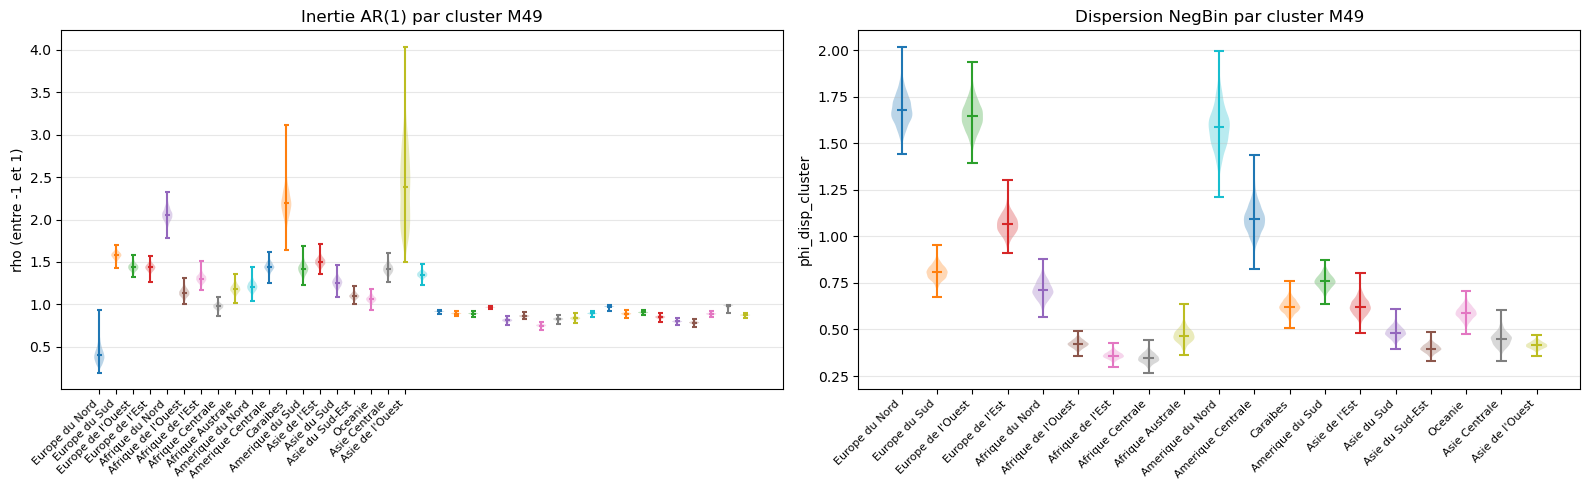

In [187]:
# Tableau des coefficients Hurdle et Volume
def print_coef_table(name, means, q05, q95, labels):
    print(f"\n[ {name} ]")
    print(f"{'Variable':<25} {'Moyenne':>10} {'IC 5%':>10} {'IC 95%':>10} {'Sig':>5}")
    print("-" * 65)
    for j in range(len(means)):
        col = labels[j] if j < len(labels) else f'[{j+1}]'
        sig = 'OUI' if (q05[j] > 0 or q95[j] < 0) else 'non'
        print(f"{col:<25} {means[j]:>10.3f} {q05[j]:>10.3f} {q95[j]:>10.3f} {sig:>5}")

# Tableau Hurdle
print_coef_table(
    'HURDLE (Logit)',
    beta_h.mean(axis=0),
    np.percentile(beta_h, 5, axis=0),   # Modifiable à 2.5 si nécessaire pour matcher le IC 95% du graphe
    np.percentile(beta_h, 95, axis=0),  # Modifiable à 97.5
    HURDLE_VARS
)

print_coef_table(
    'VOLUME (ZTNB)',
    beta_grav.mean(axis=0),
    np.percentile(beta_grav, 5, axis=0),
    np.percentile(beta_grav, 95, axis=0),
    X_VOL_COLS
)
rho_m49_draws       = df_final.filter(like='rho_m49').values
phi_cluster_draws   = df_final.filter(like='phi_disp_cluster').values
cluster_labels      = [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'cluster_{k}')
                       for k in range(1, K_clusters + 1)]

print_coef_table(
    'RHO AR(1) par cluster M49',
    rho_m49_draws.mean(axis=0),
    np.percentile(rho_m49_draws,  5, axis=0),
    np.percentile(rho_m49_draws, 95, axis=0),
    cluster_labels
)

print_coef_table(
    'PHI dispersion par cluster M49',
    phi_cluster_draws.mean(axis=0),
    np.percentile(phi_cluster_draws,  5, axis=0),
    np.percentile(phi_cluster_draws, 95, axis=0),
    cluster_labels
)

# Figure comparative rho vs phi par cluster
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, draws, title, ylabel in [
    (axes[0], rho_m49_draws,     'Inertie AR(1) par cluster M49',       'rho (entre -1 et 1)'),
    (axes[1], phi_cluster_draws, 'Dispersion NegBin par cluster M49',   'phi_disp_cluster'),
]:
    for k in range(draws.shape[1]):
        ax.violinplot(draws[:, k], positions=[k + 1], widths=0.6, showmedians=True)
    ax.set_xticks(range(1, K_clusters + 1))
    ax.set_xticklabels(cluster_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(f"rho_phi_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()

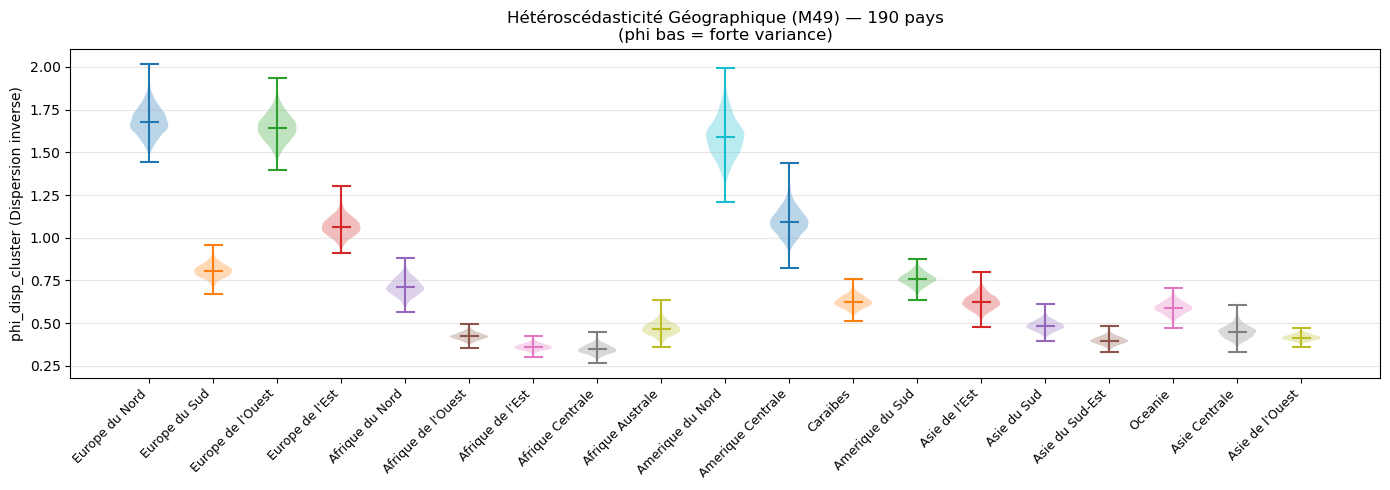

In [188]:
# Figure : hétéroscédasticité M49
fig, ax = plt.subplots(figsize=(14, 5))
for k in range(1, K_clusters + 1):
    draws_k = phi_disp_cluster[:, k-1].flatten()
    ax.violinplot(draws_k, positions=[k], widths=0.6, showmedians=True)
ax.set_xticks(range(1, K_clusters + 1))
ax.set_xticklabels(
    [SUBREGION_LABELS.get(stan_to_m49.get(k, 99), f'Cluster {k}') for k in range(1, K_clusters + 1)],
    rotation=45, ha='right', fontsize=9
)
ax.set_ylabel("phi_disp_cluster (Dispersion inverse)")
ax.set_title(f"Hétéroscédasticité Géographique (M49) — {N_pays} pays\n(phi bas = forte variance)")
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f"NegBin_dispersion_cluster_M49_{N_pays}.pdf", bbox_inches='tight')
plt.show()

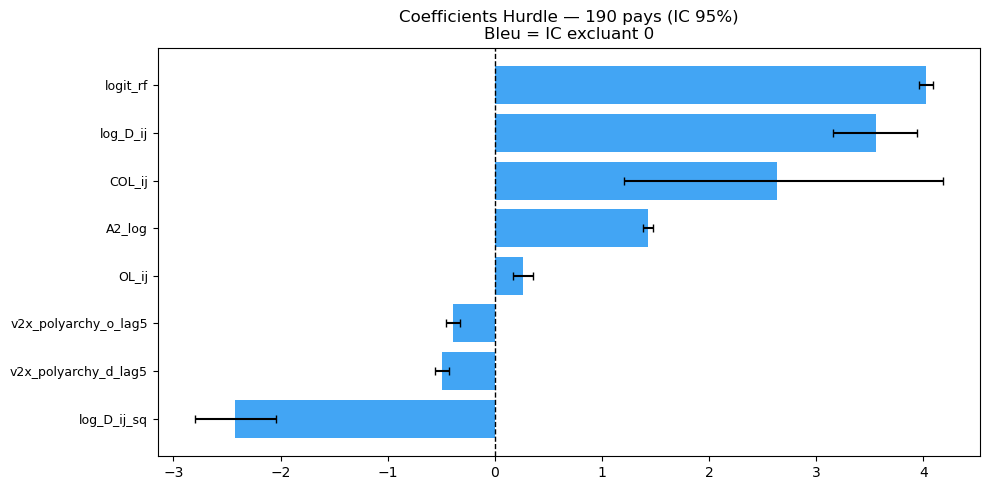

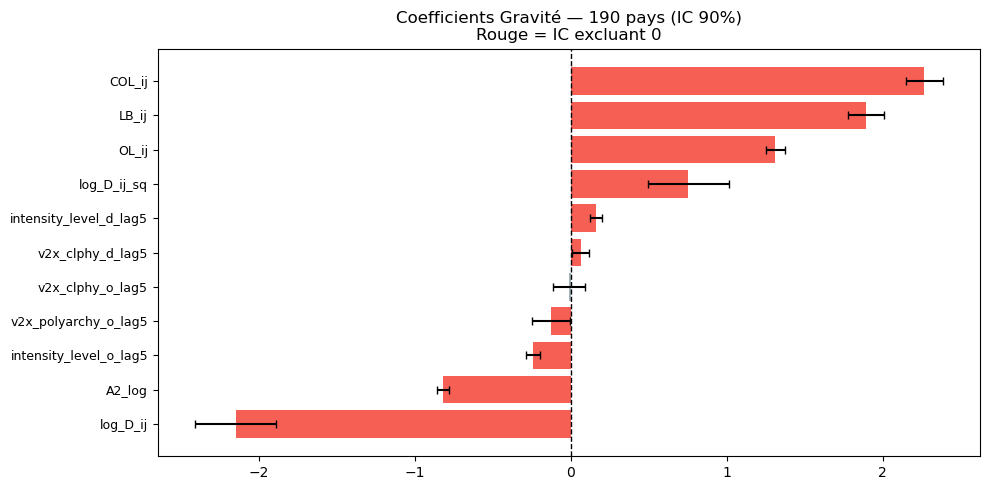

In [189]:
# Figure : coefficients Hurdle et Volume
def plot_coefs(means, q05, q95, labels, title, color_sig, fname):
    K = len(means)
    order = np.argsort(means)
    colors = [color_sig if (q05[i] > 0 or q95[i] < 0) else '#90A4AE' for i in order]
    fig, ax = plt.subplots(figsize=(10, max(5, K * 0.45)))
    ax.barh(
        range(K), means[order],
        xerr=[means[order] - q05[order], q95[order] - means[order]],
        color=colors, alpha=0.85, capsize=3
    )
    ax.set_yticks(range(K))
    ax.set_yticklabels([labels[i] for i in order], fontsize=9)
    ax.axvline(0, color='black', lw=1, ls='--')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(fname, bbox_inches='tight')
    plt.show()

# Figure : Coefficients Hurdle
plot_coefs(
    beta_h.mean(axis=0), 
    np.percentile(beta_h, 2.5, axis=0), 
    np.percentile(beta_h, 97.5, axis=0),
    HURDLE_VARS,
    f"Coefficients Hurdle — {N_pays} pays (IC 95%)\nBleu = IC excluant 0",
    '#2196F3', 
    f"NegBin_hurdle_coefficients_{N_pays}.pdf"
)

plot_coefs(
    beta_grav.mean(axis=0), np.percentile(beta_grav, 2.5, axis=0), np.percentile(beta_grav, 97.5, axis=0),
    X_VOL_COLS,
    f"Coefficients Gravité — {N_pays} pays (IC 90%)\nRouge = IC excluant 0",
    '#F44336', f"NegBin_gravity_coefficients_{N_pays}.pdf"
)

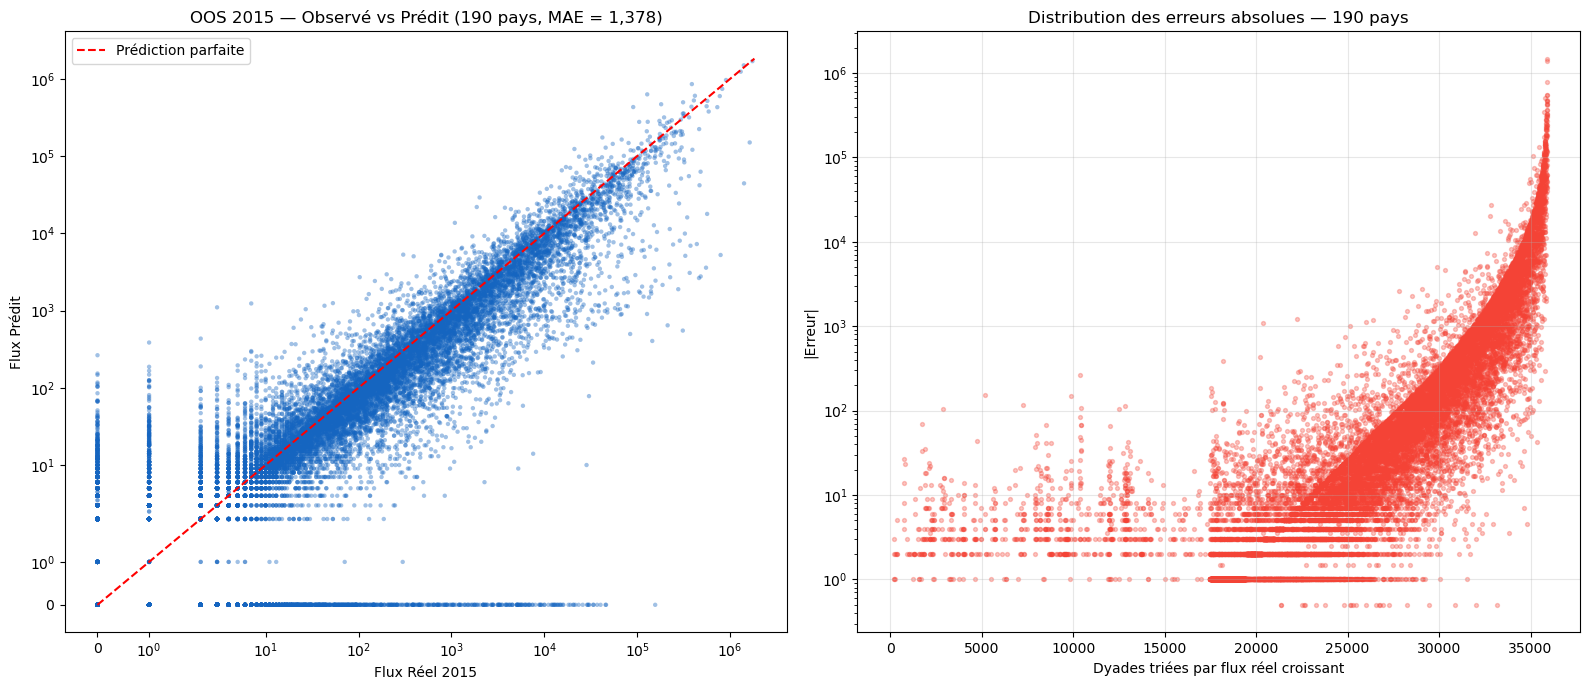

In [190]:
# Figure : scatter OOS + distribution des erreurs
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(y_true, y_pred, alpha=0.4, s=10, color='#1565C0', edgecolors='none')
lim = [0, max(y_true.max(), y_pred.max()) * 1.05]
ax.plot(lim, lim, 'r--', lw=1.5, label='Prédiction parfaite')
ax.set_xscale('symlog')
ax.set_yscale('symlog')
ax.set_xlabel("Flux Réel 2015")
ax.set_ylabel("Flux Prédit")
ax.set_title(f"OOS 2015 — Observé vs Prédit ({N_pays} pays, MAE = {global_mae:,.0f})")
ax.legend()

ax2 = axes[1]
order_err = np.argsort(y_true)
ax2.scatter(range(len(y_true)), np.abs(y_true[order_err] - y_pred[order_err]),
            alpha=0.3, s=8, color='#F44336')
ax2.set_xlabel("Dyades triées par flux réel croissant")
ax2.set_ylabel("|Erreur|")
ax2.set_yscale('log')
ax2.set_title(f"Distribution des erreurs absolues — {N_pays} pays")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"NegBin_prediction_scatter_{N_pays}.pdf", bbox_inches='tight')
plt.show()

In [202]:
# Cartographie FP / FN
import plotly.express as px

df_test['y_true_bin'] = y_true_bin
df_test['y_pred_bin'] = y_pred_bin
df_test['FN'] = ((df_test['y_true_bin'] == 1) & (df_test['y_pred_bin'] == 0)).astype(int)
df_test['FP'] = ((df_test['y_true_bin'] == 0) & (df_test['y_pred_bin'] == 1)).astype(int)

error_map = df_test.groupby('orig')[['FN', 'FP']].sum().reset_index()
print(f"FN : {df_test['FN'].sum()} | FP : {df_test['FP'].sum()}")

for col, scale, title in [
    ('FN', 'Reds',  'Cartographie Faux Négatifs (FN) par pays d\'origine'),
    ('FP', 'Blues', 'Cartographie Faux Positifs (FP) par pays d\'origine'),
]:
    fig = px.choropleth(
        error_map, locations='orig', color=col,
        hover_name='orig', color_continuous_scale=scale,
        title=title, labels={col: f'Nombre de {col}'}
    )
    fig.update_layout(geo=dict(showframe=False, showcoastlines=True, projection_type='equirectangular'))
    fig.show()

FN : 2618 | FP : 787


# diagnostics

In [192]:
fp_m = (y_pred_bin==1)&(y_test==0); fn_m=(y_pred_bin==0)&(y_test==1); tp_m=(y_pred_bin==1)&(y_test==1)
n = len(y_test); err = np.abs(y_true - y_pred)
print(f"MAE {err.mean():,.0f}")
print(f"  part FP (volume fantôme) : {y_pred[fp_m].sum()/n:,.1f} ({fp_m.sum()} dyades)")
print(f"  part FN (flux raté)      : {y_true[fn_m].sum()/n:,.1f} ({fn_m.sum()} dyades)")
print(f"  part TP (err. volume)    : {err[tp_m].sum()/n:,.1f} ({tp_m.sum()} dyades)")
print(f"  top-20 dyades = {np.sort(err)[-20:].sum()/err.sum()*100:.0f}% de la MAE totale")

MAE 1,378
  part FP (volume fantôme) : 0.2 (787 dyades)
  part FN (flux raté)      : 36.4 (2618 dyades)
  part TP (err. volume)    : 1,341.6 (15815 dyades)
  top-20 dyades = 21% de la MAE totale


In [193]:
err = np.abs(y_true - y_pred)
idx = np.argsort(err)[-20:][::-1]
cols = ['orig','dest','flow','is_mig_lag']
top = df_test.iloc[idx][cols].assign(pred=y_pred[idx], err=err[idx],
                                     lag_flow=np.expm1(df_test['log_flow_lag_clean'].values[idx]))
print(top.to_string())

      orig dest     flow  is_mig_lag      pred        err      lag_flow
34435  VEN  COL  1626478         1.0  150216.0  1476262.0  1.428147e+05
31358  SYR  TUR  1414099         1.0   44386.0  1369713.0  2.403940e+06
34533  VEN  PER   790696         1.0    5243.5   785452.5  5.418019e+03
21750  MMR  BGD   566093         1.0   17839.5   548253.5  2.732407e+04
14935  IND  ARE   550875         1.0    3589.0   547286.0  5.963233e+05
24649  NPL  IND   128236         1.0  630226.0   501990.0  5.905847e+05
15079  IND  SAU   482496         1.0    2767.0   479729.0  6.148837e+05
6226   CHN  USA   387775         1.0  855752.0   467977.0  9.279925e+05
2983   BGD  SAU   462829         1.0    2637.0   460192.0  5.169793e+05
834    ARE  IND   438411         1.0    7265.0   431146.0  3.913734e+05
32930  TUR  DEU   468711         1.0   41900.0   426811.0  5.813442e+05
31229  SYR  DEU   481407         1.0   62768.5   418638.5  1.424595e+05
15062  IND  OMN   374726         1.0    6916.5   367809.5  5.697

In [194]:
tp_m = (y_pred_bin==1)&(y_test==1)
dec = pd.qcut(y_true[tp_m], 10, labels=False, duplicates='drop')
pd.DataFrame({'dec':dec, 'bias':(y_pred-y_true)[tp_m],
              'log_res':np.log1p(y_pred[tp_m])-np.log1p(y_true[tp_m])}
            ).groupby('dec').agg(['mean','median'])

bias            log_res          
             mean   median      mean    median
dec                                           
0        6.460138     2.00  0.727554  0.405465
1        6.899231     1.00  0.292038  0.154151
2        6.283939     0.00  0.078860  0.000000
3        8.401967    -4.00 -0.123970 -0.148420
4       -1.228553   -15.00 -0.305831 -0.252155
5       -9.957278   -42.00 -0.401073 -0.323290
6      -52.441919  -101.50 -0.485014 -0.345686
7     -220.752535  -311.50 -0.575167 -0.401232
8     -868.474383  -996.50 -0.628050 -0.397473
9   -19045.029709 -6579.75 -0.807834 -0.448448

In [195]:
# ============================================================
#  DIAGNOSTIC FAMILLE (c) : décomposition mu_full / rho_d / lag par dyade
#  Sans re-run. rho_raw lu en ciblé dans les CSV (absent de vars_to_keep).
# ============================================================
watch = ['IND_ARE','IND_SAU','IND_OMN','BGD_SAU','BGD_ARE','ARE_IND','BFA_CIV',
         'NPL_IND','CHN_USA']   # 2 sur-prédits en contrôle : leur AR s'engage, lui

# --- draws déjà en RAM (mêmes lignes que mu_clean via valid_draws) ---
alpha_em_d  = df_final.filter(regex=r'^alpha_em\.').values[valid_draws]    # (S, N_pays)
gamma_at_d  = df_final.filter(regex=r'^gamma_at\.').values[valid_draws]
beta_grav_d = df_final.filter(regex=r'^beta_grav\.').values[valid_draws]   # (S, K_v)
rho_lat_d   = df_final.filter(regex=r'^rho_m49_lat\.').values[valid_draws] # (S, K)
tau_rho_d   = df_final['tau_rho'].values[valid_draws]                      # (S,)

# --- rho_raw ciblé : lecture CSV, même ordre de chains que df_final ---
need_dv = {}
for d in watch:
    row = df_volume[df_volume['dyad'] == d]
    if not row.empty:
        need_dv[d] = int(row['dyad_id_v'].iloc[0])          # 1-based Stan
rr_cols = [f'rho_raw.{v}' for v in need_dv.values()]
rr = pd.concat([pd.read_csv(f, comment='#', usecols=rr_cols, engine='c')
                for f in csv_files], ignore_index=True)[rr_cols].values[valid_draws]
rr_j = {v: j for j, v in enumerate(need_dv.values())}

# --- décomposition ---
tt  = df_test.reset_index(drop=True)
key = (tt['orig'] + '_' + tt['dest']).values
X_v_t = np.asarray(X_test_v_std)                            # (N_test, K_v), ordre Stan
clu_v = np.asarray(cluster_v)                               # (D_v,), 1-based

print(f"{'dyade':<9}{'d_v':>7}{'lag01':>6}{'lag_log':>8}{'mu_full':>8}"
      f"{'mu_dt':>8}{'rho_d':>7}{'rho_clu':>8}{'rho_impl':>9}")
for d in watch:
    n = np.where(key == d)[0]
    if len(n) == 0: print(f"{d:<9} absent de df_test"); continue
    n  = int(n[0])
    o  = int(tt['orig_id_test_v'].iloc[n]) - 1
    de = int(tt['dest_id_test_v'].iloc[n]) - 1
    lag01 = float(tt['is_mig_lag'].iloc[n]) if not pd.isna(tt['is_mig_lag'].iloc[n]) else 0.0
    lag = float(tt['log_flow_lag_clean'].iloc[n])
    mu_full_m = float(np.median(alpha_em_d[:, o] + gamma_at_d[:, de] + beta_grav_d @ X_v_t[n]))
    mu_dt_m   = float(np.median(mu_clean[:, n]))
    rho_impl  = (mu_dt_m - mu_full_m) / (lag - mu_full_m) if abs(lag - mu_full_m) > 1e-6 else np.nan
    d_v = need_dv.get(d, 0)
    if d_v > 0:
        k = int(clu_v[d_v - 1]) - 1
        rho_d_m = float(np.median(np.tanh(rho_lat_d[:, k] + tau_rho_d * rr[:, rr_j[d_v]])))
        rho_clu = float(np.tanh(np.median(rho_lat_d[:, k])))
    else:
        rho_d_m, rho_clu = np.nan, np.nan   # d_v=0 -> branche rho_global côté Stan
    print(f"{d:<9}{d_v:>7}{lag01:>6.0f}{lag:>8.2f}{mu_full_m:>8.2f}"
          f"{mu_dt_m:>8.2f}{rho_d_m:>7.3f}{rho_clu:>8.3f}{rho_impl:>9.3f}")

dyade        d_v lag01 lag_log mu_full   mu_dt  rho_d rho_clu rho_impl
IND_ARE     9366     1   13.30    9.56   12.58  0.807   0.800    0.808
IND_SAU     9501     1   13.33    9.09   12.47  0.796   0.800    0.797
IND_OMN     9484     1   13.25    9.13   12.48  0.814   0.800    0.813
BGD_SAU     1788     1   13.16    8.76   12.23  0.791   0.800    0.790
BGD_ARE     1675     1   12.87    9.07   12.13  0.805   0.800    0.805
ARE_IND      390     1   12.88    8.69   12.38  0.879   0.875    0.881
BFA_CIV     1617     1   12.66    9.63   12.21  0.854   0.863    0.852
NPL_IND    15591     1   13.29   13.79   13.38  0.804   0.800    0.819
CHN_USA     3864     1   13.74   13.60   13.72  0.811   0.851    0.852


In [196]:
key = (df_test['orig'] + '_' + df_test['dest']).values
for d in ['IND_ARE','IND_SAU','BGD_SAU','BFA_CIV','NPL_IND','CHN_USA']:
    n = int(np.where(key == d)[0][0])
    print(f"{d:<9} exp(mu) méd={np.median(np.exp(mu_clean[:, n])):>10,.0f} "
          f"| med_préd={flow_cond_med_final[n]:>10,.0f} "
          f"| phi_d méd={np.median(phi_clean[:, n]):>6.3f} "
          f"| réel={df_test['flow'].values[n]:>10,.0f}")

IND_ARE   exp(mu) méd=   290,686 | med_préd=     3,589 | phi_d méd= 0.016 | réel=   550,875
IND_SAU   exp(mu) méd=   260,407 | med_préd=     2,767 | phi_d méd= 0.014 | réel=   482,496
BGD_SAU   exp(mu) méd=   204,843 | med_préd=     2,637 | phi_d méd= 0.007 | réel=   462,829
BFA_CIV   exp(mu) méd=   200,787 | med_préd=     5,114 | phi_d méd= 0.023 | réel=   329,531
NPL_IND   exp(mu) méd=   646,934 | med_préd=   630,226 | phi_d méd= 7.089 | réel=   128,236
CHN_USA   exp(mu) méd=   908,909 | med_préd=   855,752 | phi_d méd= 5.712 | réel=   387,775


In [197]:
def metrics(yh, tag):
    yh = np.where(y_pred_bin == 1, yh, 0.0)
    mae  = np.abs(y_true - yh).mean()
    mape = (np.abs(y_true - yh) / (y_true + 1)).mean() * 100
    print(f"{tag:<26} MAE = {mae:>8,.0f} | MAPE = {mape:>6.1f}%")

lam_med = np.median(np.exp(np.clip(mu_clean, -50, 50)), axis=0)
p0      = np.exp(-phi_clean * np.log1p(np.exp(np.clip(mu_clean,-50,50) - np.log(phi_clean))))
zt_mean = np.mean(np.exp(np.clip(mu_clean,-50,50)) / np.clip(1 - p0, 1e-6, 1), axis=0)

metrics(flow_cond_med_final,                      "médiane prédictive (actuel)")
metrics(lam_med,                                  "médiane de lambda")
metrics(zt_mean,                                  "moyenne ZT lambda/(1-p0)")
metrics(np.percentile(flow_cond_sim, 75, axis=0), "q75 prédictif")

médiane prédictive (actuel) MAE =    1,378 | MAPE =   63.3%
médiane de lambda          MAE =    1,288 | MAPE =  105.8%
moyenne ZT lambda/(1-p0)   MAE =    1,958 | MAPE =  274.6%
q75 prédictif              MAE =    1,679 | MAPE =  196.1%


In [198]:
for d in ['IND_ARE','IND_SAU','BGD_SAU','BFA_CIV','NPL_IND','CHN_USA']:
    sub = df_volume[df_volume['dyad'] == d]
    print(f"--- {d}")
    print(sub[['year','flow','is_mig_lag','is_emergent_v','log_flow_lag']].to_string(index=False))

--- IND_ARE
 year    flow  is_mig_lag  is_emergent_v  log_flow_lag
 1990  238439         0.0              1       0.00000
 1995  268429         1.0              0      12.38187
 2000  626387         1.0              0      12.50034
 2005 1559458         1.0              0      13.34772
 2010  596327         1.0              0      14.25985
--- IND_SAU
 year   flow  is_mig_lag  is_emergent_v  log_flow_lag
 1990 185946         0.0              1       0.00000
 1995 122595         1.0              0      12.13321
 2000 231070         1.0              0      11.71664
 2005 254237         1.0              0      12.35048
 2010 614883         1.0              0      12.44602
--- BGD_SAU
 year   flow  is_mig_lag  is_emergent_v  log_flow_lag
 1990 168866         0.0              1       0.00000
 1995  60803         1.0              0      12.03686
 2000 236811         1.0              0      11.01539
 2005 387849         1.0              0      12.37502
 2010 516982         1.0              0 

In [199]:
from scipy.stats import gamma as _gamma
sub  = np.linspace(0, mu_clean.shape[0]-1, 200).astype(int)   # 200 draws suffisent
lam_s, phi_s = np.exp(np.clip(mu_clean[sub], -50, 50)), phi_clean[sub]
for fl in [0.0, 0.05, 0.1, 0.25, 0.5, 1.0]:
    pe = np.clip(phi_s, max(fl, 1e-8), None)
    yh = np.median(lam_s * _gamma.ppf(0.5, a=pe, scale=1.0/pe), axis=0)
    metrics(yh, f"médiane, phi >= {fl}")

médiane, phi >= 0.0        MAE =    1,403 | MAPE =   41.2%
médiane, phi >= 0.05       MAE =    1,403 | MAPE =   41.2%
médiane, phi >= 0.1        MAE =    1,402 | MAPE =   41.2%
médiane, phi >= 0.25       MAE =    1,358 | MAPE =   46.8%
médiane, phi >= 0.5        MAE =    1,282 | MAPE =   61.8%
médiane, phi >= 1.0        MAE =    1,230 | MAPE =   78.3%


In [200]:
fp_m = (y_pred_bin==1)&(y_test==0); fn_m=(y_pred_bin==0)&(y_test==1); tp_m=(y_pred_bin==1)&(y_test==1)
n = len(y_true)

def decomp(yh, tag):
    yhm = np.where(y_pred_bin == 1, yh, 0.0)
    ape = np.abs(y_true - yhm) / (y_true + 1)
    print(f"{tag:<26} MAPE={ape.mean()*100:>6.1f}% "
          f"(FP {ape[fp_m].sum()/n*100:>5.1f} | FN {ape[fn_m].sum()/n*100:>5.1f} | TP {ape[tp_m].sum()/n*100:>5.1f}) "
          f"| MAE={np.abs(y_true-yhm).mean():>8,.0f} "
          f"| part ŷ<1 : {(yhm[y_pred_bin==1] < 1).mean()*100:>4.0f}%")

decomp(flow_cond_med_final, "médiane NB2 (actuel)")
decomp(np.median(lam_s * _gamma.ppf(0.5, a=np.clip(phi_s,1e-8,None), scale=1/np.clip(phi_s,1e-8,None)), axis=0),
       "médiane lambda*nu")
decomp(np.maximum(flow_cond_med_final, 0) * 0 + np.round(np.median(lam_s * _gamma.ppf(0.5, a=np.clip(phi_s,1e-8,None), scale=1/np.clip(phi_s,1e-8,None)), axis=0)),
       "idem, arrondi entier")

médiane NB2 (actuel)       MAPE=  63.3% (FP  18.6 | FN   5.2 | TP  39.5) | MAE=   1,378 | part ŷ<1 :    0%
médiane lambda*nu          MAPE=  41.2% (FP   7.2 | FN   5.2 | TP  28.8) | MAE=   1,403 | part ŷ<1 :   14%
idem, arrondi entier       MAPE=  41.2% (FP   7.3 | FN   5.2 | TP  28.7) | MAE=   1,403 | part ŷ<1 :    8%


In [201]:
# --- mu_full sur le TRAIN (médianes posterior) ---
a_m, g_m, b_m = (np.median(alpha_em_d, 0), np.median(gamma_at_d, 0), np.median(beta_grav_d, 0))
Xv = np.asarray(X_vol_std)
mu_full_tr = (a_m[df_volume['orig_id_v'].astype(int).values - 1]
              + g_m[df_volume['dest_id_v'].astype(int).values - 1]
              + Xv @ b_m)

# --- phi_d par dyade, récupéré via les lignes de test (d_v > 0) ---
key_t  = (df_test['orig'] + '_' + df_test['dest']).values
phi_med = np.median(phi_clean, axis=0)
phi_by_dyad = {}
for n in range(len(df_test)):
    if int(df_test['dyad_id_test_v'].iloc[n]) > 0:
        phi_by_dyad.setdefault(key_t[n], phi_med[n])

# --- résidu 1990 vs phi_d ---
m90 = (df_volume['year'].values == df_volume['year'].min())
r90 = np.log(df_volume['flow'].values[m90]) - mu_full_tr[m90]      # écart au niveau structurel
d90 = df_volume['dyad'].values[m90]
ok  = np.array([d in phi_by_dyad for d in d90])
lp  = np.log(np.array([phi_by_dyad[d] for d in d90[ok]]))
print(f"n = {ok.sum():,} | corr(residu_1990, log phi_d) = {np.corrcoef(r90[ok], lp)[0,1]:+.3f}")
for lo, hi in [(-99,1),(1,2),(2,3),(3,4),(4,99)]:
    m = (r90[ok] >= lo) & (r90[ok] < hi)
    if m.sum(): print(f"  residu 1990 in [{lo},{hi}) : n={m.sum():>5,} | phi_d méd = {np.exp(np.median(lp[m])):>7.3f}")

n = 17,254 | corr(residu_1990, log phi_d) = +0.121
  residu 1990 in [-99,1) : n=17,197 | phi_d méd =   0.779
  residu 1990 in [1,2) : n=   40 | phi_d méd =   0.022
  residu 1990 in [2,3) : n=   16 | phi_d méd =   0.009
  residu 1990 in [3,4) : n=    1 | phi_d méd =   0.016
